# Silver 02a — Subset Builder and Clean-Normal Constructor

### Ask

What is this notebook doing?

### Answer

This notebook builds the profiled Silver subset that I use to separate cleaner normal behavior from normal rows that may already be contaminated by early fault behavior.

The goal is not just to keep every row labeled `normal`. Instead, I want to identify which normal rows are stable enough to use as a better reference for downstream modeling and synthetic generation.

This notebook:

- loads the Silver Pre-EDA output
- resolves the parent truth record and feature registry
- normalizes the source machine-status labels
- builds normal episode windows
- scores normal windows against sensor behavior
- creates `machine_status__profiled`
- separates `normal_clean`, `normal_contaminated`, `abnormal`, and `recovery`
- saves subset artifacts for Silver 02b, Gold preprocessing, and the synthetic generator

## Environment Setup and Utility Imports

### Ask

Why am I starting with imports and utility setup?

### Answer

Before I build the profiled Silver subset, I need the notebook environment to have access to the same project utilities used by the rest of the pipeline.

This setup loads the libraries for dataframe work, plotting, configuration loading, artifact writing, lineage tracking, logging, and truth-record handling. I am not changing the data yet. I am preparing the notebook so the later subset-building steps can run in a repeatable way.

In [50]:
from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple, cast
import json
import logging
import math
import re
import wandb
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from utils.core.paths import get_paths

from utils.core.file_io import (
    load_data, 
    save_json, 
    load_json,
)
from utils.core.logging_setup import (
    configure_logging, 
    log_layer_paths,
)

from utils.core.ledger import Ledger

from utils.core.truths import (
    make_process_run_id,
    identify_meta_columns,
    load_parent_truth_record_from_dataframe,
    get_dataset_name_from_truth,
    get_truth_hash,
    get_parent_truth_hash,
    get_artifact_path_from_truth,
    extract_truth_hash,
    get_pipeline_mode_from_truth,
    get_truth_value,
    initialize_layer_truth,
    update_truth_section,
    build_truth_record,
    save_truth_record,
    append_truth_index,
)

from utils.core.config_loader import (
    load_pipeline_config,
    build_truth_config_block,
    set_wandb_dir_from_config,
    export_config_snapshot,
)

from utils.core.artifacts import (
    build_artifact_dirs_from_config,
    artifact_file_path,
)

from utils.database.postgres import (
    get_engine_from_env, 
    read_sql_dataframe,
)
from utils.database.layer_postgres import (
    read_layer_dataframe, 
    write_layer_dataframe, 
    prepare_layer_dataframe,
)

from utils.database.sql_notebook_helpers import (
    delete_dataset_run_rows,
    execute_many,
    get_existing_dataframe,
    get_row_value,
    log_data_quality_event,
    log_pipeline_artifact,
    preview_sql_table,
    row_to_payload,
    sql_table_ref,
    to_builtin,
    to_json_string,
    to_scalar,
    upsert_pipeline_run,
)

from utils.database.medallion_sql_writers import (
    log_gold_05_anomaly_detection_summary_sql,
    log_silver_eda_sql,
    write_bronze_sensor_observations_sql,
    write_gold_baseline_scores_sql,
    write_gold_cascade_scores_sql,
    write_gold_model_comparison_results_sql,
    write_gold_preprocessed_features_sql,
    write_silver_sensor_observation_features_sql,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)
pd.set_option("display.max_rows", 200)

## Environment Setup and Utility Imports

### Ask

Why am I starting with imports and utility setup?

### Answer

Before I build the profiled Silver subset, I need the notebook environment to have access to the same project utilities used by the rest of the pipeline.

This setup loads the libraries for dataframe work, plotting, configuration loading, artifact writing, lineage tracking, logging, and truth-record handling. I am not changing the data yet. I am preparing the notebook so the later subset-building steps can run in a repeatable way.

In [51]:
paths = get_paths()

CONFIG_ROOT = paths.configs
CONFIG_RUN_MODE = "train"
CONFIG_PROFILE = "default"

CONFIG = load_pipeline_config(
    config_root=CONFIG_ROOT,
    stage="silver_eda",
    dataset="pump",
    mode=CONFIG_RUN_MODE,
    profile=CONFIG_PROFILE,
    project_root=paths.root,
).data


SILVER_EDA_CFG = CONFIG["silver_eda"]
PATHS = CONFIG["resolved_paths"]
FILENAMES = CONFIG["filenames"]
PIPELINE = CONFIG.get(
    "pipeline",
    {
        "execution_mode": "batch",
        "orchestration_mode": "notebook",
    },
)

TRUTH_CONFIG = build_truth_config_block(CONFIG)
TRUTH_CONFIG["pipeline"] = PIPELINE

STAGE = "silver_subsets"
LAYER_NAME = "silver_subsets"
SILVER_VERSION = CONFIG["versions"]["silver_eda"]
CLEANING_RECIPE_ID = SILVER_EDA_CFG["cleaning_recipe_id"]
PIPELINE_MODE = PIPELINE["execution_mode"]
RUN_MODE = CONFIG["runtime"]["mode"]

DATASET_NAME_CONFIG = CONFIG["dataset"]["name"]

SILVER_PROCESS_RUN_ID = make_process_run_id(SILVER_EDA_CFG["process_run_id_prefix"])

#### #### #### #### 
# Weights and Biases

WANDB_PROJECT = CONFIG["wandb"]["project"]
WANDB_ENTITY = CONFIG["wandb"]["entity"]
WANDB_RUN_NAME = f"{SILVER_VERSION}"

#### #### #### #### 

BRONZE_TRAIN_DATA_PATH = Path(PATHS["data_bronze_train_dir"])
SILVER_TRAIN_DATA_PATH = Path(PATHS["data_silver_train_dir"])

ARTIFACTS_ROOT = Path(PATHS["artifacts_root"])
TRUTHS_PATH = Path(PATHS["truths_dir"])
TRUTH_INDEX_PATH = Path(PATHS["truth_index_path"])
LOGS_PATH = Path(PATHS["logs_root"])

# Canonical Silver EDA artifact roots.
# Final subdirectories are resolved in the artifact-dir cell below.
SILVER_EDA_ARTIFACTS_ROOT = ARTIFACTS_ROOT / "silver" / str(DATASET_NAME_CONFIG) / "eda"
SILVER_SUBSET_ARTIFACTS_ROOT = SILVER_EDA_ARTIFACTS_ROOT / "subsets"

SILVER_TRAIN_DATA_FILE_NAME = str(FILENAMES["silver_train_file_name"])

SILVER_SUBSET_PROCESS_RUN_ID = make_process_run_id("silver_subset_process")

TRUTHS_PATH.mkdir(parents=True, exist_ok=True)
LOGS_PATH.mkdir(parents=True, exist_ok=True)
SILVER_EDA_ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)
SILVER_SUBSET_ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)

print("CONFIG dataset:", DATASET_NAME_CONFIG)
print("Silver input dir:", SILVER_TRAIN_DATA_PATH)
print("Subset artifact root:", SILVER_SUBSET_ARTIFACTS_ROOT)

set_wandb_dir_from_config(CONFIG)

CONFIG dataset: pump
Silver input dir: /workspace/data/silver/train
Subset artifact root: /workspace/artifacts/silver/pump/eda/subsets


PosixPath('/workspace/wandb')

----

In [52]:
SILVER_SUBSET_ARTIFACT_DIRS = build_artifact_dirs_from_config(
    config=CONFIG,
    stage_key="silver_eda",
)

# Force Silver EDA outputs into the same canonical layout style as Silver PreEDA:
# artifacts/silver/<dataset>/eda/
SILVER_SUBSET_ARTIFACT_DIR = SILVER_EDA_ARTIFACTS_ROOT

SENSOR_PROFILE_DIR = SILVER_SUBSET_ARTIFACT_DIR / "sensor_profiles"
CORRELATION_ARTIFACT_DIR = SILVER_SUBSET_ARTIFACT_DIR / "correlation_analysis"
PCA_ARTIFACT_DIR = SILVER_SUBSET_ARTIFACT_DIR / "pca"
DISTRIBUTION_PLOT_DIR = SILVER_SUBSET_ARTIFACT_DIR / "distribution_plots"
GENERATOR_INPUT_DIR = SILVER_SUBSET_ARTIFACT_DIR / "generator_inputs"
SILVER_SUBSET_SUMMARY_DIR = SILVER_SUBSET_ARTIFACT_DIR / "summaries"
SILVER_SUBSET_METADATA_DIR = SILVER_SUBSET_ARTIFACT_DIR / "metadata"
SILVER_SUBSET_CONFIG_DIR = SILVER_SUBSET_ARTIFACT_DIR / "config"
SILVER_SUBSET_LINEAGE_DIR = SILVER_SUBSET_ARTIFACT_DIR / "lineage"
SILVER_SUBSET_OUTPUT_DIR = SILVER_SUBSET_ARTIFACT_DIR / "subsets"

for artifact_dir in [
    SILVER_SUBSET_ARTIFACT_DIR,
    SENSOR_PROFILE_DIR,
    CORRELATION_ARTIFACT_DIR,
    PCA_ARTIFACT_DIR,
    DISTRIBUTION_PLOT_DIR,
    GENERATOR_INPUT_DIR,
    SILVER_SUBSET_SUMMARY_DIR,
    SILVER_SUBSET_METADATA_DIR,
    SILVER_SUBSET_CONFIG_DIR,
    SILVER_SUBSET_LINEAGE_DIR,
    SILVER_SUBSET_OUTPUT_DIR,
]:
    artifact_dir.mkdir(parents=True, exist_ok=True)

CONFIG_SNAPSHOT_PATH = (
    SILVER_SUBSET_CONFIG_DIR
    / f"{DATASET_NAME_CONFIG}__silver_subsets__resolved_config.yaml"
)

if CONFIG["execution"].get("save_config_snapshot", True):
    export_config_snapshot(
        CONFIG,
        destination=CONFIG_SNAPSHOT_PATH,
    )

print("Silver EDA artifact root:", SILVER_SUBSET_ARTIFACT_DIR)
print("Silver subset output dir:", SILVER_SUBSET_OUTPUT_DIR)

Silver EDA artifact root: /workspace/artifacts/silver/pump/eda
Silver subset output dir: /workspace/artifacts/silver/pump/eda/subsets


---

### SQL Runtime Context
Purpose:
Establish the Postgres connection and resolve the dataset/run identifiers used by SQL logging and medallion table writes.


In [53]:

engine = get_engine_from_env()

CAPSTONE_SCHEMA = os.getenv("CAPSTONE_SCHEMA", "capstone")

DATASET_ID = os.getenv(
    "SYNTHETIC_DATASET_ID",
    globals().get("DATASET_NAME", "pump_synthetic_v1"),
)

RUN_ID = os.getenv(
    "SYNTHETIC_RUN_ID",
    globals().get("RUN_ID", "synthetic_run_001"),
)

print(f"SQL schema: {CAPSTONE_SCHEMA}")
print(f"Dataset ID: {DATASET_ID}")
print(f"Run ID: {RUN_ID}")


SQL schema: capstone
Dataset ID: pump_synthetic_v1
Run ID: synthetic_run_001


In [54]:

# =============================================================================
# SQL Smoke Check
# Purpose:
#   Confirm the database connection and expected capstone schemas/tables exist.
# =============================================================================

sql_smoke_check_dataframe = read_sql_dataframe(
    engine,
    """
    SELECT
        table_schema,
        table_name
    FROM information_schema.tables
    WHERE table_schema IN (:capstone_schema, 'bronze', 'silver', 'gold', 'metadata')
    ORDER BY table_schema, table_name
    """,
    params={"capstone_schema": CAPSTONE_SCHEMA},
)

display(sql_smoke_check_dataframe)

,table_schema,table_name
0,bronze,sensor_observations
1,capstone,bronze_observations_input_stage
2,capstone,data_quality_events
3,capstone,pipeline_artifacts
4,capstone,pipeline_runs
5,capstone,simulation_state_control
6,capstone,simulation_timing_config
7,capstone,synthetic_observations_premelt_stage
8,capstone,synthetic_observations_timestamped_stage
9,capstone,synthetic_pump_stream


---

## Start Logging for the Silver Subset Stage

### Ask

Why turn logging on this early?

### Answer

This notebook makes several filtering and classification decisions, so I want a log record of the run before those decisions happen.

The log helps me trace which paths were used, which dataset was loaded, what major steps ran, and where any failure happened. That makes this notebook easier to debug and easier to convert into a pipeline step later.

In [55]:
subset_log_path = LOGS_PATH / "silver_subsets.log"
    
configure_logging(
    "capstone",
    subset_log_path,
    level=logging.INFO,
    overwrite_handlers=True,
)

logger = logging.getLogger("capstone.silver_subsets")
logger.info("Silver subset builder starting")
log_layer_paths(paths, current_layer="silver", logger=logger)

print("Logging to:", subset_log_path)

2026-06-02 05:08:12,083 | INFO | capstone.silver_subsets | Silver subset builder starting
2026-06-02 05:08:12,086 | INFO | capstone.silver_subsets | Project Root Path Loaded: /workspace
2026-06-02 05:08:12,087 | INFO | capstone.silver_subsets | Project Logging Path Loaded: /workspace/logs
2026-06-02 05:08:12,090 | INFO | capstone.silver_subsets | Project Artifacts Path Loaded: /workspace/artifacts
2026-06-02 05:08:12,092 | INFO | capstone.silver_subsets | Project Notebooks Path Loaded: /workspace/notebooks
2026-06-02 05:08:12,094 | INFO | capstone.silver_subsets | Project Truths Path Loaded: /workspace/artifacts/truths
2026-06-02 05:08:12,096 | INFO | capstone.silver_subsets | Project Data Path Loaded: /workspace/data
2026-06-02 05:08:12,097 | INFO | capstone.silver_subsets | Previous Layer (Bronze) Path Loaded: /workspace/data/bronze
2026-06-02 05:08:12,098 | INFO | capstone.silver_subsets | Previous Layer (Bronze) Training Path Loaded: /workspace/data/bronze/train
2026-06-02 05:08:12

Logging to: /workspace/logs/silver_subsets.log


---

In [56]:
# W&B
'''
wandb_run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name=WANDB_RUN_NAME,
    job_type="silver_eda",
    config={
        "silver_version": SILVER_VERSION,
        "cleaning_recipe_id": CLEANING_RECIPE_ID,
        "silver_path": str(SILVER_TRAIN_DATA_PATH / SILVER_TRAIN_DATA_FILE_NAME),
        "silver_out_dir": str(SILVER_TRAIN_DATA_PATH),
    },
)
logger.info("W&B initialized: %s", wandb.run.name)
'''


'\nwandb_run = wandb.init(\n    project=WANDB_PROJECT,\n    entity=WANDB_ENTITY,\n    name=WANDB_RUN_NAME,\n    job_type="silver_eda",\n    config={\n        "silver_version": SILVER_VERSION,\n        "cleaning_recipe_id": CLEANING_RECIPE_ID,\n        "silver_path": str(SILVER_TRAIN_DATA_PATH / SILVER_TRAIN_DATA_FILE_NAME),\n        "silver_out_dir": str(SILVER_TRAIN_DATA_PATH),\n    },\n)\nlogger.info("W&B initialized: %s", wandb.run.name)\n'

----

## Start Logging for the Silver Subset Stage

### Ask

Why turn logging on this early?

### Answer

This notebook makes several filtering and classification decisions, so I want a log record of the run before those decisions happen.

The log helps me trace which paths were used, which dataset was loaded, what major steps ran, and where any failure happened. That makes this notebook easier to debug and easier to convert into a pipeline step later.

In [57]:
ledger = Ledger(stage=STAGE, recipe_id="silver_subsets__v001")

ledger.add(
    kind="step",
    step="init",
    message="Initialized Silver subset-builder ledger.",
    logger=logger,
)

print("Ledger initialized.")

2026-06-02 05:08:12,132 | INFO | capstone.silver_subsets | LEDGER | {'ts_utc': '2026-06-02T05:08:12.132724+00:00', 'stage': 'silver_subsets', 'recipe': 'silver_subsets__v001', 'kind': 'step', 'step': 'init', 'message': 'Initialized Silver subset-builder ledger.', 'why': None, 'consequence': None, 'data': {}}


Ledger initialized.


---

## Load the Silver Pre-EDA Output

### Ask

What data am I loading into this notebook?

### Answer

This cell loads the finalized Silver Pre-EDA dataframe that was created by the earlier Silver 01 notebook.

That Silver output already contains the cleaned schema, canonical metadata, anomaly flag, feature list context, and lineage information. Silver 02a builds on that foundation instead of starting from the raw or Bronze dataset again.

In [58]:
# =========================================================
# Load Silver dataframe
# =========================================================

preferred_silver_path = SILVER_TRAIN_DATA_PATH / SILVER_TRAIN_DATA_FILE_NAME

if preferred_silver_path.exists():
    silver_data_path = preferred_silver_path
else:
    parquet_candidates = sorted(SILVER_TRAIN_DATA_PATH.glob("*.parquet"))
    if not parquet_candidates:
        raise FileNotFoundError(f"No Silver parquet files found in {SILVER_TRAIN_DATA_PATH}")
    silver_data_path = parquet_candidates[0]
    if len(parquet_candidates) > 1:
        logger.warning("Multiple Silver parquet files found. Using first: %s", silver_data_path)

silver_eda_df = load_data(silver_data_path.parent, silver_data_path.name)

logger.info("Loaded Silver dataframe: %s | shape=%s", silver_data_path, silver_eda_df.shape)

ledger.add(
    kind="step",
    step="load_silver",
    message="Loaded Silver dataframe.",
    data={
        "silver_path": str(silver_data_path),
        "shape": list(silver_eda_df.shape),
        "column_count": int(len(silver_eda_df.columns)),
    },
    logger=logger,
)

print("Loaded:", silver_data_path)
print("Shape:", silver_eda_df.shape)

display(silver_eda_df.head(3))

2026-06-02 05:08:12,153 | INFO | capstone.file_io | Loading Parquet: /workspace/data/silver/train/pump__silver__train.parquet
2026-06-02 05:08:12,977 | INFO | capstone.silver_subsets | Loaded Silver dataframe: /workspace/data/silver/train/pump__silver__train.parquet | shape=(220320, 73)
2026-06-02 05:08:12,979 | INFO | capstone.silver_subsets | LEDGER | {'ts_utc': '2026-06-02T05:08:12.979460+00:00', 'stage': 'silver_subsets', 'recipe': 'silver_subsets__v001', 'kind': 'step', 'step': 'load_silver', 'message': 'Loaded Silver dataframe.', 'why': None, 'consequence': None, 'data': {'silver_path': '/workspace/data/silver/train/pump__silver__train.parquet', 'shape': [220320, 73], 'column_count': 73}}


Loaded: /workspace/data/silver/train/pump__silver__train.parquet
Shape: (220320, 73)


,meta__asset_id,meta__dataset,meta__episode_id,meta__event_id,meta__ingested_at_utc,meta__parent_truth_hash,meta__pipeline_mode,meta__record_id,meta__run_id,meta__source_file,meta__source_row_id,meta__split,meta__truth_hash,event_time,event_step,time_index,event_date,anomaly_flag,is_anomaly,is_normal,status_normal_value,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,sensor_28,sensor_29,sensor_30,sensor_31,sensor_32,sensor_33,sensor_34,sensor_35,sensor_36,sensor_37,sensor_38,sensor_39,sensor_40,sensor_41,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_51,timestamp,machine_status
0,asset__001,pump,0,pump:asset__001:run__001:0,2026-06-02 04:50:00.299056+00:00,65fc2fb9e5fc2892d89db066e4321189eb738065762b29...,batch,14598431322315673869,run__001,sensor.csv,0,unsplit,0f2c8895d670e24b98d928dd04011749d253b335098ac1...,2018-04-01 00:00:00+00:00,0,0,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,2.465394,47.09201,53.2118,46.31076,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,37.22740,47.52422,31.11716,1.681353,419.5747,461.8781,466.3284,2.565284,665.3993,398.9862,880.0001,498.8926,975.9409,627.6740,741.7151,848.0708,429.0377,785.1935,684.9443,594.4445,682.8125,680.4416,433.7037,171.9375,341.9039,195.0655,90.32386,40.36458,31.51042,70.57291,30.98958,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,201.3889,2018-04-01 00:00:00,NORMAL
1,asset__001,pump,0,pump:asset__001:run__001:1,2026-06-02 04:50:00.299056+00:00,65fc2fb9e5fc2892d89db066e4321189eb738065762b29...,batch,15954729095895098000,run__001,sensor.csv,1,unsplit,0f2c8895d670e24b98d928dd04011749d253b335098ac1...,2018-04-01 00:01:00+00:00,1,1,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,2.465394,47.09201,53.2118,46.31076,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,37.22740,47.52422,31.11716,1.681353,419.5747,461.8781,466.3284,2.565284,665.3993,398.9862,880.0001,498.8926,975.9409,627.6740,741.7151,848.0708,429.0377,785.1935,684.9443,594.4445,682.8125,680.4416,433.7037,171.9375,341.9039,195.0655,90.32386,40.36458,31.51042,70.57291,30.98958,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,201.3889,2018-04-01 00:01:00,NORMAL
2,asset__001,pump,0,pump:asset__001:run__001:2,2026-06-02 04:50:00.299056+00:00,65fc2fb9e5fc2892d89db066e4321189eb738065762b29...,batch,10041703297090838359,run__001,sensor.csv,2,unsplit,0f2c8895d670e24b98d928dd04011749d253b335098ac1...,2018-04-01 00:02:00+00:00,2,2,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,2.444734,47.35243,53.2118,46.39757,638.8889,73.54598,13.32465,16.03733,15.61777,15.01013,37.86777,48.17723,32.08894,1.708474,420.8480,462.7798,459.6364,2.500062,666.2234,399.9418,880.4237,501.3617,982.7342,631.1326,740.8031,849.8997,454.2390,778.5734,715.6266,661.5740,721.8750,694.7721,441.2635,169.9820,343.1955,200.9694,93.90508,41.40625,31.25000,69.53125,30.46875,31.770830,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,203.7037,2018-04-01 00:02:00,NORMAL


## Load the Silver Pre-EDA Output

### Ask

What data am I loading into this notebook?

### Answer

This cell loads the finalized Silver Pre-EDA dataframe that was created by the earlier Silver 01 notebook.

That Silver output already contains the cleaned schema, canonical metadata, anomaly flag, feature list context, and lineage information. Silver 02a builds on that foundation instead of starting from the raw or Bronze dataset again.

In [59]:
# =========================================================
# Resolve truth / dataset identity / artifact dirs
# =========================================================

SILVER_TRUTH_HASH = extract_truth_hash(silver_eda_df)

if SILVER_TRUTH_HASH is None:
    raise ValueError("Could not resolve meta__truth_hash from Silver dataframe.")

SILVER_DATASET_NAME = (
    silver_eda_df["meta__dataset"]
    .dropna()
    .astype("string")
    .str.strip()
)
SILVER_DATASET_NAME = SILVER_DATASET_NAME[SILVER_DATASET_NAME != ""]

if len(SILVER_DATASET_NAME) == 0:
    raise ValueError("Silver dataframe is missing usable meta__dataset values.")

SILVER_DATASET_NAME = str(SILVER_DATASET_NAME.iloc[0]).strip()

silver_truth = load_parent_truth_record_from_dataframe(
    dataframe=silver_eda_df,
    truth_dir=TRUTHS_PATH,
    parent_layer_name="silver",
    dataset_name=SILVER_DATASET_NAME,
    column_name="meta__truth_hash",
)

DATASET_NAME = get_dataset_name_from_truth(silver_truth)
SILVER_TRUTH_HASH = get_truth_hash(silver_truth)
SILVER_PARENT_TRUTH_HASH = get_parent_truth_hash(silver_truth)

PIPELINE_MODE_FROM_TRUTH = get_pipeline_mode_from_truth(silver_truth)
if PIPELINE_MODE_FROM_TRUTH is not None:
    PIPELINE_MODE = PIPELINE_MODE_FROM_TRUTH

SILVER_TRUTH_PATH = (
    TRUTHS_PATH
    / "silver"
    / f"{DATASET_NAME}__silver__truth__{SILVER_TRUTH_HASH}.json"
)

LABEL_SOURCE_COLUMN = get_truth_value(
    silver_truth,
    "runtime_facts",
    "label_resolution",
    "label_source_column",
    required=False,
)

LABEL_SOURCE_TYPE = get_truth_value(
    silver_truth,
    "runtime_facts",
    "label_resolution",
    "label_source_type",
    required=False,
)

CANONICAL_INFO = silver_truth.get("runtime_facts", {}).get("canonical_info", {})
FEATURE_SET_INFO = silver_truth.get("runtime_facts", {}).get("feature_set", {})
QUALITY_INFO = silver_truth.get("runtime_facts", {}).get("quality_info", {})

NEEDS_ONE_HOT_ENCODING = bool(
    silver_truth.get("needs_one_hot_encoding", False)
)
ONE_HOT_ENCODING_COLUMNS = list(
    silver_truth.get("one_hot_encoding_columns", [])
)

feature_registry_dir = get_artifact_path_from_truth(
    silver_truth,
    "feature_registry_dir",
)
FEATURE_REGISTRY_FILE_NAME = f"{DATASET_NAME}__silver__feature_registry.json"
FEATURE_REGISTRY_PATH = Path(feature_registry_dir) / "registry" / FEATURE_REGISTRY_FILE_NAME

#SILVER_SUBSET_ARTIFACT_DIR = SILVER_SUBSET_ARTIFACTS_ROOT / DATASET_NAME
#SILVER_SUBSET_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

SILVER_SUBSET_TRUTH_DIR = TRUTHS_PATH / "silver_subsets"
SILVER_SUBSET_TRUTH_DIR.mkdir(parents=True, exist_ok=True)

logger.info("Loaded Silver truth: %s", SILVER_TRUTH_PATH)
logger.info("Resolved dataset name from Silver truth: %s", DATASET_NAME)
logger.info("Resolved label source column from Silver truth: %s", LABEL_SOURCE_COLUMN)

ledger.add(
    kind="step",
    step="resolve_truth",
    message="Resolved Silver truth, dataset identity, and subset artifact directories.",
    data={
        "dataset_name": DATASET_NAME,
        "silver_truth_hash": SILVER_TRUTH_HASH,
        "silver_parent_truth_hash": SILVER_PARENT_TRUTH_HASH,
        "silver_truth_path": str(SILVER_TRUTH_PATH),
        "label_source_column": LABEL_SOURCE_COLUMN,
        "label_source_type": LABEL_SOURCE_TYPE,
        "feature_registry_path": str(FEATURE_REGISTRY_PATH),
        "subset_artifact_dir": str(SILVER_SUBSET_ARTIFACT_DIR),
        "subset_truth_dir": str(SILVER_SUBSET_TRUTH_DIR),
    },
    logger=logger,
)

print("Loaded Silver truth:", SILVER_TRUTH_PATH)
print("Silver truth hash:", SILVER_TRUTH_HASH)
print("Resolved dataset name:", DATASET_NAME)
print("Resolved label source column:", LABEL_SOURCE_COLUMN)
print("Feature registry path:", FEATURE_REGISTRY_PATH)
print("Subset artifact dir:", SILVER_SUBSET_ARTIFACT_DIR)

2026-06-02 05:08:13,192 | INFO | capstone.silver_subsets | Loaded Silver truth: /workspace/artifacts/truths/silver/pump__silver__truth__0f2c8895d670e24b98d928dd04011749d253b335098ac1e14d0dba518356af1e.json
2026-06-02 05:08:13,194 | INFO | capstone.silver_subsets | Resolved dataset name from Silver truth: pump
2026-06-02 05:08:13,195 | INFO | capstone.silver_subsets | Resolved label source column from Silver truth: machine_status
2026-06-02 05:08:13,198 | INFO | capstone.silver_subsets | LEDGER | {'ts_utc': '2026-06-02T05:08:13.197991+00:00', 'stage': 'silver_subsets', 'recipe': 'silver_subsets__v001', 'kind': 'step', 'step': 'resolve_truth', 'message': 'Resolved Silver truth, dataset identity, and subset artifact directories.', 'why': None, 'consequence': None, 'data': {'dataset_name': 'pump', 'silver_truth_hash': '0f2c8895d670e24b98d928dd04011749d253b335098ac1e14d0dba518356af1e', 'silver_parent_truth_hash': '65fc2fb9e5fc2892d89db066e4321189eb738065762b2985fed497518b029240', 'silver_tr

Loaded Silver truth: /workspace/artifacts/truths/silver/pump__silver__truth__0f2c8895d670e24b98d928dd04011749d253b335098ac1e14d0dba518356af1e.json
Silver truth hash: 0f2c8895d670e24b98d928dd04011749d253b335098ac1e14d0dba518356af1e
Resolved dataset name: pump
Resolved label source column: machine_status
Feature registry path: /workspace/artifacts/silver/pump/preeda/registry/pump__silver__feature_registry.json
Subset artifact dir: /workspace/artifacts/silver/pump/eda


## Load the Feature Registry and Sensor Columns

### Ask

Why do I need the feature registry here?

### Answer

The feature registry tells this notebook which columns should be treated as actual sensor/modeling features.

That matters because the subset-building logic should evaluate sensor behavior, not metadata, identifiers, labels, or helper columns. Loading the registry here keeps Silver 02a aligned with the feature decisions already made in Silver 01.

In [60]:
if FEATURE_REGISTRY_PATH is None:
    raise ValueError(
        "FEATURE_REGISTRY_PATH was not resolved from Silver truth before loading the feature registry."
    )

feature_registry_raw = load_json(
    FEATURE_REGISTRY_PATH.parent,
    FEATURE_REGISTRY_PATH.name,
)

if feature_registry_raw is None:
    raise ValueError(
        f"Feature registry JSON loaded as None: {FEATURE_REGISTRY_PATH}"
    )

if not isinstance(feature_registry_raw, dict):
    raise TypeError(
        "Feature registry must be a dictionary, "
        f"got {type(feature_registry_raw).__name__}: {FEATURE_REGISTRY_PATH}"
    )

feature_registry = cast(Dict[str, Any], feature_registry_raw)

feature_columns_raw = feature_registry.get("feature_columns", [])

if feature_columns_raw is None:
    feature_columns_raw = []

if not isinstance(feature_columns_raw, list):
    raise TypeError(
        "Feature registry key 'feature_columns' must be a list, "
        f"got {type(feature_columns_raw).__name__}: {FEATURE_REGISTRY_PATH}"
    )

FEATURE_COLUMNS = [
    str(col).strip()
    for col in feature_columns_raw
    if str(col).strip() != ""
]

if len(FEATURE_COLUMNS) == 0:
    raise ValueError(
        f"Feature registry was loaded but feature_columns is empty: {FEATURE_REGISTRY_PATH}"
    )

# Keep only features that actually exist in the dataframe
missing_feature_columns = [
    col
    for col in FEATURE_COLUMNS
    if col not in silver_eda_df.columns
]

if missing_feature_columns:
    logger.warning(
        "Some feature registry columns were not found in the dataframe and will be skipped: %s",
        missing_feature_columns[:20],
    )

FEATURE_COLUMNS = [
    col
    for col in FEATURE_COLUMNS
    if col in silver_eda_df.columns
]

if len(FEATURE_COLUMNS) == 0:
    raise ValueError(
        "After intersecting the feature registry with dataframe columns, no usable feature columns remained."
    )

CONFIG_SENSOR_COLUMNS = FEATURE_COLUMNS

meta_columns = identify_meta_columns(silver_eda_df)
meta_column_set = set(meta_columns)

logger.info("Loaded Silver Feature Registry: %s", FEATURE_REGISTRY_PATH)

ledger.add(
    kind="step",
    step="load_silver_feature_registry",
    message="Loaded Silver Feature Registry JSON file using the path resolved from Silver truth.",
    why="Silver subset building should inherit resolved feature metadata from Silver rather than rebuilding it from config.",
    consequence="Subset building uses the same resolved feature set and feature registry lineage as prior Silver stages.",
    data={
        "feature_registry_path": str(FEATURE_REGISTRY_PATH),
        "keys": int(len(feature_registry)),
        "feature_count": int(len(FEATURE_COLUMNS)),
        "missing_feature_column_count": int(len(missing_feature_columns)),
        "feature_sample": FEATURE_COLUMNS[:10],
    },
    logger=logger,
)

# wandb_run.log({"feature_registry_keys": int(len(feature_registry))})

print("Loaded Silver Feature Registry:", FEATURE_REGISTRY_PATH)
print("Feature registry keys:", int(len(feature_registry)))
print("Feature column count:", int(len(FEATURE_COLUMNS)))
print("First 10 feature columns:", FEATURE_COLUMNS[:10])

2026-06-02 05:08:13,227 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/silver/pump/preeda/registry/pump__silver__feature_registry.json
2026-06-02 05:08:13,246 | INFO | capstone.silver_subsets | Loaded Silver Feature Registry: /workspace/artifacts/silver/pump/preeda/registry/pump__silver__feature_registry.json
2026-06-02 05:08:13,248 | INFO | capstone.silver_subsets | LEDGER | {'ts_utc': '2026-06-02T05:08:13.248016+00:00', 'stage': 'silver_subsets', 'recipe': 'silver_subsets__v001', 'kind': 'step', 'step': 'load_silver_feature_registry', 'message': 'Loaded Silver Feature Registry JSON file using the path resolved from Silver truth.', 'why': 'Silver subset building should inherit resolved feature metadata from Silver rather than rebuilding it from config.', 'consequence': 'Subset building uses the same resolved feature set and feature registry lineage as prior Silver stages.', 'data': {'feature_registry_path': '/workspace/artifacts/silver/pump/preeda/registry/pump__silver

Loaded Silver Feature Registry: /workspace/artifacts/silver/pump/preeda/registry/pump__silver__feature_registry.json
Feature registry keys: 17
Feature column count: 50
First 10 feature columns: ['sensor_00', 'sensor_01', 'sensor_02', 'sensor_03', 'sensor_04', 'sensor_05', 'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09']


## Source State Normalization

### Ask

Why am I normalizing the source machine-status labels?

### Answer

The original status labels need to be consistent before I can build profiled states.

This cell resolves the source status column and maps the values into a cleaner state field. I want the later logic to work from stable labels such as `normal`, `abnormal`, and `recovery` instead of depending on inconsistent raw source values.

In [61]:

STATE_COL_SOURCE_RAW = None
STATE_COL_SOURCE = "machine_status__synthetic"

for candidate_col in [
    "machine_status__synthetic",
    "machine_status",
    "status",
    "state",
]:
    if candidate_col in silver_eda_df.columns:
        STATE_COL_SOURCE_RAW = candidate_col
        break

if STATE_COL_SOURCE_RAW is None:
    raise KeyError(
        "Could not resolve a source state column. Expected one of: "
        "machine_status__synthetic, machine_status, status, state"
    )

def normalize_machine_state(value: Any) -> str:
    text = str(value).strip().lower()

    if text in {"normal", "norm", "ok"}:
        return "normal"

    if text in {"broken", "abnormal", "fault", "failure", "failed"}:
        return "abnormal"

    if text in {"recovering", "recovery", "cooldown", "cooling"}:
        return "recovery"

    return text

if STATE_COL_SOURCE_RAW == STATE_COL_SOURCE:
    silver_eda_df[STATE_COL_SOURCE] = (
        silver_eda_df[STATE_COL_SOURCE]
        .astype("string")
        .str.strip()
        .str.lower()
    )
else:
    silver_eda_df[STATE_COL_SOURCE] = silver_eda_df[STATE_COL_SOURCE_RAW].map(normalize_machine_state)

logger.info(
    "Resolved source-state column: raw=%s -> normalized=%s",
    STATE_COL_SOURCE_RAW,
    STATE_COL_SOURCE,
)

ledger.add(
    kind="step",
    step="normalize_source_state",
    message="Built normalized source-state column.",
    data={
        "source_state_raw_column": STATE_COL_SOURCE_RAW,
        "source_state_normalized_column": STATE_COL_SOURCE,
    },
    logger=logger,
)

display(
    silver_eda_df[
        [c for c in [STATE_COL_SOURCE_RAW, STATE_COL_SOURCE] if c in silver_eda_df.columns]
    ].head(10)
)

2026-06-02 05:08:13,405 | INFO | capstone.silver_subsets | Resolved source-state column: raw=machine_status -> normalized=machine_status__synthetic
2026-06-02 05:08:13,408 | INFO | capstone.silver_subsets | LEDGER | {'ts_utc': '2026-06-02T05:08:13.408132+00:00', 'stage': 'silver_subsets', 'recipe': 'silver_subsets__v001', 'kind': 'step', 'step': 'normalize_source_state', 'message': 'Built normalized source-state column.', 'why': None, 'consequence': None, 'data': {'source_state_raw_column': 'machine_status', 'source_state_normalized_column': 'machine_status__synthetic'}}


,machine_status,machine_status__synthetic
0,NORMAL,normal
1,NORMAL,normal
2,NORMAL,normal
3,NORMAL,normal
4,NORMAL,normal
5,NORMAL,normal
6,NORMAL,normal
7,NORMAL,normal
8,NORMAL,normal
9,NORMAL,normal


## Review Source State Counts

### Ask

What am I checking after normalizing the source states?

### Answer

After creating the normalized source-state column, I count the rows in each state.

This is a quick validation step. If the counts look wrong here, then the subset logic would be working from bad labels. I want to confirm the normal, abnormal, and recovery populations before using them to build clean-normal profiles.

In [62]:
# =========================================================
# Quick source-state summary
# =========================================================

source_state_counts_df = (
    silver_eda_df[STATE_COL_SOURCE]
    .value_counts(dropna=False)
    .rename_axis(STATE_COL_SOURCE)
    .reset_index(name="row_count")
)

source_state_counts_df["row_pct"] = (
    source_state_counts_df["row_count"] / len(silver_eda_df)
)

ledger.add(
    kind="step",
    step="source_state_summary",
    message="Built quick source-state summary.",
    data={
        "source_state_counts": source_state_counts_df.to_dict(orient="records"),
    },
    logger=logger,
)

display(source_state_counts_df)

2026-06-02 05:08:13,446 | INFO | capstone.silver_subsets | LEDGER | {'ts_utc': '2026-06-02T05:08:13.446421+00:00', 'stage': 'silver_subsets', 'recipe': 'silver_subsets__v001', 'kind': 'step', 'step': 'source_state_summary', 'message': 'Built quick source-state summary.', 'why': None, 'consequence': None, 'data': {'source_state_counts': [{'machine_status__synthetic': 'normal', 'row_count': 205836, 'row_pct': 0.9342592592592592}, {'machine_status__synthetic': 'recovery', 'row_count': 14477, 'row_pct': 0.06570896877269426}, {'machine_status__synthetic': 'abnormal', 'row_count': 7, 'row_pct': 3.177196804647785e-05}]}}


,machine_status__synthetic,row_count,row_pct
0,normal,205836,0.934259
1,recovery,14477,0.065709
2,abnormal,7,0.000032


----

## Define Normal Episode Edge Trimming

### Ask

Why trim the edges of normal episodes?

### Answer

Rows near the beginning or end of a normal episode may be less reliable as clean-normal examples.

The end of a normal episode may be close to fault buildup, and the beginning may be close to recovery or transition behavior. Trimming helps reduce the chance that contaminated boundary rows become part of the clean-normal baseline.

In [63]:
# =========================================================
# Subset-builder configuration
# =========================================================

# Use the normalized source-state column created above. This avoids mixed
# casing such as NORMAL / normal and keeps all downstream profiling logic
# using the same state values.
LABEL_COLUMN = STATE_COL_SOURCE
NORMAL_VALUES = ["normal"]

# Prefer the feature registry columns when available, then fall back to
# dataframe sensor_* columns. This keeps the subset builder aligned with
# the Silver feature lineage.
if "CONFIG_SENSOR_COLUMNS" in globals() and len(CONFIG_SENSOR_COLUMNS) > 0:
    SENSOR_COLUMNS = [
        col for col in CONFIG_SENSOR_COLUMNS
        if str(col).startswith("sensor_") and col in silver_eda_df.columns
    ]
else:
    SENSOR_COLUMNS = [
        col for col in silver_eda_df.columns
        if str(col).startswith("sensor_")
    ]

if len(SENSOR_COLUMNS) == 0:
    raise ValueError("No sensor_* columns were resolved for profiling.")

# Window-baseline settings
TRIM_FRAC = 0.10
WINDOWS_PER_EPISODE = 5
KEEP_WINDOW_FRAC = 0.80
MIN_WINDOW_ROWS = 500

# Row scoring settings
VALUE_DEVIATION_THRESHOLD = 8.0
DELTA_DEVIATION_THRESHOLD = 5.0
SUSPECT_SENSOR_COUNT = 8
EXCLUDE_SENSOR_COUNT = 21

# Metadata label used in summary/truth artifacts
FINAL_METHOD = "trimmed_normal_episode_sensor_profile"

config_summary_df = pd.DataFrame(
    [
        {"setting": "label_column", "value": LABEL_COLUMN},
        {"setting": "normal_values", "value": str(NORMAL_VALUES)},
        {"setting": "sensor_count", "value": len(SENSOR_COLUMNS)},
        {"setting": "trim_frac", "value": TRIM_FRAC},
        {"setting": "windows_per_episode", "value": WINDOWS_PER_EPISODE},
        {"setting": "keep_window_frac", "value": KEEP_WINDOW_FRAC},
        {"setting": "min_window_rows", "value": MIN_WINDOW_ROWS},
        {"setting": "value_deviation_threshold", "value": VALUE_DEVIATION_THRESHOLD},
        {"setting": "delta_deviation_threshold", "value": DELTA_DEVIATION_THRESHOLD},
        {"setting": "suspect_sensor_count", "value": SUSPECT_SENSOR_COUNT},
        {"setting": "exclude_sensor_count", "value": EXCLUDE_SENSOR_COUNT},
        {"setting": "final_method", "value": FINAL_METHOD},
    ]
)

display(config_summary_df)

,setting,value
0,label_column,machine_status__synthetic
1,normal_values,['normal']
2,sensor_count,50
3,trim_frac,0.1
4,windows_per_episode,5
5,keep_window_frac,0.8
6,min_window_rows,500
7,value_deviation_threshold,8.0
8,delta_deviation_threshold,5.0
9,suspect_sensor_count,8


## Configure Normal Episode Windowing

### Ask

Why am I building normal windows instead of scoring every normal row immediately?

### Answer

I want the clean-normal reference to come from stable stretches of normal behavior, not from isolated rows that may sit near an anomaly boundary.

This section defines the label column, sensor columns, trimming rules, episode-window settings, and quality thresholds that control how normal windows are created and filtered.

In [64]:
def assign_normal_episodes(
    dataframe,
    label_column,
    normal_values,
):
    working_df = dataframe.copy()

    normal_mask = working_df[label_column].isin(normal_values)

    # A new group starts whenever normal/non-normal status changes
    status_change = normal_mask.ne(normal_mask.shift(fill_value=False))

    working_df["__status_group"] = status_change.cumsum()
    working_df["__is_normal_candidate"] = normal_mask

    # Only assign episode IDs to normal rows
    working_df["__normal_episode_id"] = np.where(
        normal_mask,
        working_df["__status_group"],
        np.nan,
    )

    return working_df

## Define Normal Episode Edge Trimming

### Ask

Why trim the edges of normal episodes?

### Answer

Rows near the beginning or end of a normal episode may be less reliable as clean-normal examples.

The end of a normal episode may be close to fault buildup, and the beginning may be close to recovery or transition behavior. Trimming helps reduce the chance that contaminated boundary rows become part of the clean-normal baseline.

In [65]:
def trim_normal_episode_edges(
    dataframe,
    trim_frac=0.10,
    min_rows_after_trim=1000,
):
    working_df = dataframe.copy()
    working_df["__keep_after_episode_trim"] = False

    normal_episode_ids = (
        working_df["__normal_episode_id"]
        .dropna()
        .unique()
    )

    for episode_id in normal_episode_ids:
        episode_mask = working_df["__normal_episode_id"].eq(episode_id)
        episode_index = working_df.index[episode_mask]

        episode_row_count = len(episode_index)

        trim_count = int(episode_row_count * trim_frac)

        if episode_row_count - (2 * trim_count) < min_rows_after_trim:
            continue

        kept_index = episode_index[trim_count : episode_row_count - trim_count]

        working_df.loc[kept_index, "__keep_after_episode_trim"] = True

    return working_df

## Create Windows Inside Normal Episodes

### Ask

Why split normal episodes into smaller windows?

### Answer

Windowing lets me compare chunks of normal behavior instead of treating the whole episode as equally clean.

Some windows may be very stable while others may show higher spread, missingness, or early abnormal behavior. Breaking episodes into windows gives me a better way to select the strongest normal reference sections.

In [66]:
def create_episode_windows(
    dataframe,
    windows_per_episode=5,
    min_window_rows=500,
):
    working_df = dataframe.copy()
    working_df["__window_id"] = np.nan

    kept_df = working_df[working_df["__keep_after_episode_trim"]].copy()

    window_counter = 0

    for episode_id, episode_df in kept_df.groupby("__normal_episode_id"):
        episode_indices = episode_df.index.to_numpy()

        if len(episode_indices) < min_window_rows:
            continue

        window_splits = np.array_split(episode_indices, windows_per_episode)

        for local_window_id, window_indices in enumerate(window_splits, start=1):
            if len(window_indices) < min_window_rows:
                continue

            window_label = f"episode_{int(episode_id)}__window_{local_window_id}"

            working_df.loc[window_indices, "__window_id"] = window_label

            window_counter += 1

    return working_df

## Calculate Sensor Statistics by Window

### Ask

What statistics am I calculating here?

### Answer

This helper summarizes sensor behavior inside each normal window.

I am looking at values such as spread, missingness, and sensor-level stability so that each window can be scored. The purpose is to identify which normal windows look most stable and useful for defining clean-normal behavior.

In [67]:
def calculate_window_sensor_stats(
    dataframe,
    sensor_columns,
):
    window_stats = []

    window_df = dataframe[dataframe["__window_id"].notna()].copy()

    for window_id, group_df in window_df.groupby("__window_id"):
        sensor_values = group_df[sensor_columns]

        sensor_deltas = sensor_values.diff()

        for sensor in sensor_columns:
            values = sensor_values[sensor]
            deltas = sensor_deltas[sensor].dropna()

            q25 = values.quantile(0.25)
            q75 = values.quantile(0.75)

            delta_q25 = deltas.quantile(0.25)
            delta_q75 = deltas.quantile(0.75)

            window_stats.append(
                {
                    "window_id": window_id,
                    "sensor": sensor,
                    "row_count": len(values),
                    "missing_pct": values.isna().mean(),

                    # value baseline stats
                    "median": values.median(),
                    "mean": values.mean(),
                    "std": values.std(),
                    "q05": values.quantile(0.05),
                    "q25": q25,
                    "q75": q75,
                    "q95": values.quantile(0.95),
                    "iqr": q75 - q25,

                    # delta baseline stats
                    "delta_median": deltas.median(),
                    "delta_mean": deltas.mean(),
                    "delta_std": deltas.std(),
                    "delta_abs_median": deltas.abs().median(),
                    "delta_abs_q95": deltas.abs().quantile(0.95),
                    "delta_iqr": delta_q75 - delta_q25,
                }
            )

    return pd.DataFrame(window_stats)

## Score and Filter Normal Windows

### Ask

How do I decide which normal windows are good enough to keep?

### Answer

This helper scores each normal window based on quality indicators like sensor variation and missingness.

The best windows become stronger candidates for the clean-normal baseline. This helps prevent weak or noisy normal sections from driving the downstream profile.

In [68]:
def score_and_filter_windows(
    window_sensor_stats_df,
    keep_window_frac=0.80,
):
    window_quality_df = (
        window_sensor_stats_df
        .groupby("window_id", as_index=False)
        .agg(
            window_row_count=("row_count", "median"),
            window_sensor_count=("sensor", "count"),
            window_missing_pct=("missing_pct", "mean"),
            window_median_iqr=("iqr", "median"),
            window_median_delta_abs_q95=("delta_abs_q95", "median"),
        )
    )

    window_quality_df["iqr_rank_pct"] = (
        window_quality_df["window_median_iqr"].rank(pct=True)
    )

    window_quality_df["delta_rank_pct"] = (
        window_quality_df["window_median_delta_abs_q95"].rank(pct=True)
    )

    window_quality_df["missing_rank_pct"] = (
        window_quality_df["window_missing_pct"].rank(pct=True)
    )

    window_quality_df["window_quality_score"] = (
        window_quality_df["iqr_rank_pct"]
        + window_quality_df["delta_rank_pct"]
        + window_quality_df["missing_rank_pct"]
    ) / 3

    cutoff_score = window_quality_df["window_quality_score"].quantile(keep_window_frac)

    window_quality_df["window_quality_class"] = np.where(
        window_quality_df["window_quality_score"] <= cutoff_score,
        "keep",
        "exclude",
    )

    return window_quality_df

## Build the Final Sensor Baseline

### Ask

What is the final sensor baseline used for?

### Answer

The final baseline summarizes normal sensor behavior using the windows that passed the quality filter.

This baseline becomes the reference point for scoring rows later. In other words, it gives me a data-driven picture of what stable normal operation looks like for each sensor.

In [69]:
def build_final_sensor_baseline(
    window_sensor_stats_df,
    window_quality_df,
):
    kept_windows = window_quality_df.loc[
        window_quality_df["window_quality_class"].eq("keep"),
        "window_id"
    ]

    kept_window_stats_df = window_sensor_stats_df[
        window_sensor_stats_df["window_id"].isin(kept_windows)
    ].copy()

    final_baseline_df = (
        kept_window_stats_df
        .groupby("sensor", as_index=False)
        .agg(
            baseline_window_count=("window_id", "count"),
            baseline_row_count=("row_count", "sum"),

            baseline_median=("median", "median"),
            baseline_mean=("mean", "median"),
            baseline_std=("std", "median"),

            baseline_q05=("q05", "median"),
            baseline_q25=("q25", "median"),
            baseline_q75=("q75", "median"),
            baseline_q95=("q95", "median"),
            baseline_iqr=("iqr", "median"),

            baseline_delta_median=("delta_median", "median"),
            baseline_delta_abs_median=("delta_abs_median", "median"),
            baseline_delta_abs_q95=("delta_abs_q95", "median"),
            baseline_delta_iqr=("delta_iqr", "median"),

            baseline_missing_pct=("missing_pct", "mean"),
        )
    )

    return final_baseline_df, kept_window_stats_df

## Run the Normal Windowing Workflow

### Ask

What happens when I execute the windowing functions?

### Answer

This cell applies the normal episode assignment, edge trimming, window creation, window scoring, and final baseline construction.

The output is a set of normal-window quality results and a sensor baseline that can be used to score individual rows against clean-normal behavior.

In [70]:
normal_profile_df = assign_normal_episodes(
    silver_eda_df,
    label_column=LABEL_COLUMN,
    normal_values=NORMAL_VALUES,
)

normal_profile_df = trim_normal_episode_edges(
    normal_profile_df,
    trim_frac=TRIM_FRAC,
    min_rows_after_trim=1000,
)

normal_profile_df = create_episode_windows(
    normal_profile_df,
    windows_per_episode=WINDOWS_PER_EPISODE,
    min_window_rows=MIN_WINDOW_ROWS,
)

window_sensor_stats_df = calculate_window_sensor_stats(
    normal_profile_df,
    sensor_columns=SENSOR_COLUMNS,
)

window_quality_df = score_and_filter_windows(
    window_sensor_stats_df,
    keep_window_frac=KEEP_WINDOW_FRAC,
)

final_sensor_baseline_df, kept_window_stats_df = build_final_sensor_baseline(
    window_sensor_stats_df,
    window_quality_df,
)

/tmp/ipykernel_27434/2367871502.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'episode_1__window_1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  working_df.loc[window_indices, "__window_id"] = window_label


## Review the Lowest-Scoring Normal Windows

### Ask

Why inspect the weakest normal windows?

### Answer

The lowest-scoring windows help me understand what the filter is excluding.

If these windows show high missingness, instability, or unusual sensor behavior, then the quality scoring is doing what I expect. If they look clean, then the scoring thresholds may need to be adjusted.

In [71]:
display(window_quality_df.sort_values("window_quality_score").head(10))

,window_id,window_row_count,window_sensor_count,window_missing_pct,window_median_iqr,window_median_delta_abs_q95,iqr_rank_pct,delta_rank_pct,missing_rank_pct,window_quality_score,window_quality_class
4,episode_11__window_5,752.0,50,0.000000,3.651578,2.658905,0.050,0.100,0.4,0.183333,keep
2,episode_11__window_3,752.0,50,0.000000,4.714237,2.598548,0.275,0.075,0.4,0.250000,keep
9,episode_13__window_5,4043.0,50,0.000000,4.267938,2.995783,0.125,0.400,0.4,0.308333,keep
21,episode_3__window_2,1026.0,50,0.000000,3.917237,3.065190,0.075,0.450,0.4,0.308333,keep
24,episode_3__window_5,1025.0,50,0.000000,3.981318,3.009468,0.100,0.425,0.4,0.308333,keep
30,episode_7__window_1,1146.0,50,0.000000,5.068273,2.848713,0.350,0.250,0.4,0.333333,keep
0,episode_11__window_1,752.0,50,0.000000,5.468750,2.740880,0.475,0.150,0.4,0.341667,keep
34,episode_7__window_5,1145.0,50,0.000000,5.078125,2.889222,0.375,0.275,0.4,0.350000,keep
36,episode_9__window_2,7943.0,50,0.000000,4.629631,3.080700,0.225,0.475,0.4,0.366667,keep
1,episode_11__window_2,752.0,50,0.000505,3.626240,2.781262,0.025,0.175,0.9,0.366667,keep


In [72]:
display(window_quality_df["window_quality_class"].value_counts())

window_quality_class
keep       32
exclude     8
Name: count, dtype: int64

In [73]:
display(final_sensor_baseline_df.head())

,sensor,baseline_window_count,baseline_row_count,baseline_median,baseline_mean,baseline_std,baseline_q05,baseline_q25,baseline_q75,baseline_q95,baseline_iqr,baseline_delta_median,baseline_delta_abs_median,baseline_delta_abs_q95,baseline_delta_iqr,baseline_missing_pct
0,sensor_00,32,122917,2.455556,2.453934,0.021657,2.420139,2.451620,2.467853,2.499827,0.012297,0.0,0.006886,0.014757,0.012789,0.000023
1,sensor_01,32,122917,47.547740,47.346137,1.072892,45.811630,46.614581,48.328993,49.435765,1.736110,0.0,0.043400,0.130205,0.086800,0.000813
2,sensor_02,32,122917,50.911455,51.110853,0.889568,49.621308,50.347219,51.909720,52.794049,1.302080,0.0,0.000005,0.086810,0.043403,0.000023
3,sensor_03,32,122917,43.294272,43.532453,1.164481,41.905381,42.773436,44.357635,45.768227,1.736111,0.0,0.000000,0.043410,0.000000,0.000023
4,sensor_04,32,122917,631.481400,631.438685,6.059047,622.022568,627.488400,635.474500,642.201985,7.986100,0.0,5.208300,15.740700,10.368550,0.000023


In [74]:
display(final_sensor_baseline_df.shape)

(50, 16)

## Save the Sensor Baseline Artifact

### Ask

Why save the baseline profile now?

### Answer

The sensor baseline is one of the key artifacts created by this notebook.

Saving it allows Silver 02b, the synthetic generator, and later Gold work to reference the same clean-normal profile without recalculating it every time. This also makes the subset-building decision easier to review later.

In [75]:
# =========================================================
# Save sensor baseline profiles to JSON / CSV
# =========================================================

BASELINE_EXPORT_DIR = SENSOR_PROFILE_DIR
BASELINE_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

baseline_table_path = BASELINE_EXPORT_DIR / "silver_sensor_baseline_profiles.csv"
final_sensor_baseline_df.to_csv(baseline_table_path, index=False)

json_ready_baseline_df = (
    final_sensor_baseline_df
    .replace([np.inf, -np.inf], np.nan)
    .where(pd.notna(final_sensor_baseline_df), None)
)

sensor_profiles_dict = (
    json_ready_baseline_df
    .set_index("sensor")
    .to_dict(orient="index")
)

sensor_baseline_json = {
    "artifact_type": "sensor_baseline_profile",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "source_notebook": "EDA_Notebook_Pump_Silver_02a_EDA_Building_Subsets_v3",
    "profile_method": FINAL_METHOD,
    "state_column_used_for_profile": LABEL_COLUMN,
    "normal_values_used_for_profile": NORMAL_VALUES,
    "baseline_config": {
        "trim_frac": TRIM_FRAC,
        "windows_per_episode": WINDOWS_PER_EPISODE,
        "keep_window_frac": KEEP_WINDOW_FRAC,
        "min_window_rows": MIN_WINDOW_ROWS,
        "value_deviation_threshold": VALUE_DEVIATION_THRESHOLD,
        "delta_deviation_threshold": DELTA_DEVIATION_THRESHOLD,
        "suspect_sensor_count": SUSPECT_SENSOR_COUNT,
        "exclude_sensor_count": EXCLUDE_SENSOR_COUNT,
    },
    "summary": {
        "sensor_count": int(final_sensor_baseline_df["sensor"].nunique()),
        "baseline_rows_per_sensor_median": float(final_sensor_baseline_df["baseline_row_count"].median()),
        "baseline_windows_per_sensor_median": float(final_sensor_baseline_df["baseline_window_count"].median()),
    },
    "sensor_profiles": sensor_profiles_dict,
    "baseline_table_path": str(baseline_table_path),
}

baseline_json_path = BASELINE_EXPORT_DIR / "silver_sensor_baseline_profiles.json"

with open(baseline_json_path, "w", encoding="utf-8") as file:
    json.dump(sensor_baseline_json, file, indent=2, default=str)

ledger.add(
    kind="artifact",
    step="save_sensor_baseline_profiles",
    message="Saved per-sensor baseline profile JSON and CSV artifacts.",
    data={
        "baseline_json_path": str(baseline_json_path),
        "baseline_table_path": str(baseline_table_path),
        "sensor_count": int(final_sensor_baseline_df["sensor"].nunique()),
    },
    logger=logger,
)

print("Saved sensor profile JSON:", baseline_json_path)
print("Saved sensor profile table:", baseline_table_path)

display(final_sensor_baseline_df.head())


2026-06-02 05:08:35,338 | INFO | capstone.silver_subsets | LEDGER | {'ts_utc': '2026-06-02T05:08:35.338281+00:00', 'stage': 'silver_subsets', 'recipe': 'silver_subsets__v001', 'kind': 'artifact', 'step': 'save_sensor_baseline_profiles', 'message': 'Saved per-sensor baseline profile JSON and CSV artifacts.', 'why': None, 'consequence': None, 'data': {'baseline_json_path': '/workspace/artifacts/silver/pump/eda/sensor_profiles/silver_sensor_baseline_profiles.json', 'baseline_table_path': '/workspace/artifacts/silver/pump/eda/sensor_profiles/silver_sensor_baseline_profiles.csv', 'sensor_count': 50}}


Saved sensor profile JSON: /workspace/artifacts/silver/pump/eda/sensor_profiles/silver_sensor_baseline_profiles.json
Saved sensor profile table: /workspace/artifacts/silver/pump/eda/sensor_profiles/silver_sensor_baseline_profiles.csv


,sensor,baseline_window_count,baseline_row_count,baseline_median,baseline_mean,baseline_std,baseline_q05,baseline_q25,baseline_q75,baseline_q95,baseline_iqr,baseline_delta_median,baseline_delta_abs_median,baseline_delta_abs_q95,baseline_delta_iqr,baseline_missing_pct
0,sensor_00,32,122917,2.455556,2.453934,0.021657,2.420139,2.451620,2.467853,2.499827,0.012297,0.0,0.006886,0.014757,0.012789,0.000023
1,sensor_01,32,122917,47.547740,47.346137,1.072892,45.811630,46.614581,48.328993,49.435765,1.736110,0.0,0.043400,0.130205,0.086800,0.000813
2,sensor_02,32,122917,50.911455,51.110853,0.889568,49.621308,50.347219,51.909720,52.794049,1.302080,0.0,0.000005,0.086810,0.043403,0.000023
3,sensor_03,32,122917,43.294272,43.532453,1.164481,41.905381,42.773436,44.357635,45.768227,1.736111,0.0,0.000000,0.043410,0.000000,0.000023
4,sensor_04,32,122917,631.481400,631.438685,6.059047,622.022568,627.488400,635.474500,642.201985,7.986100,0.0,5.208300,15.740700,10.368550,0.000023


----

## Define Sensor Profile Display and Plot Helpers

### Ask

Why add plotting helpers here?

### Answer

After building the sensor baseline, I want a quick way to inspect individual sensors and compare their behavior against the baseline.

These helper functions make the notebook easier to review because I can visually check whether the generated profiles look reasonable before using them for row scoring.

In [76]:
# =========================================================
# Sensor profile display and plotting helpers
# =========================================================

from IPython.display import display


def display_sensor_profile(
    baseline_df,
    sensor_name,
):
    """
    Display one sensor's learned normal profile as a readable metric table.

    The profile is one row per sensor in final_sensor_baseline_df. This
    function pivots that row vertically so it is easier to inspect in the
    notebook.
    """
    sensor_rows = baseline_df.loc[baseline_df["sensor"].eq(sensor_name)]

    if sensor_rows.empty:
        raise ValueError(f"Sensor {sensor_name!r} was not found in baseline_df.")

    profile_df = (
        sensor_rows
        .iloc[0]
        .rename("value")
        .reset_index()
        .rename(columns={"index": "metric"})
    )

    display(profile_df)
    return profile_df


def plot_sensor_profile_with_baseline(
    dataframe,
    baseline_df,
    sensor_name,
    *,
    index_column=None,
    quality_column="final_row_quality_class",
    value_flag_column=None,
    delta_flag_column=None,
    figsize=(16, 6),
    show_delta=True,
    max_points=None,
    save_dir=None,
    show_plot=True,
):
    """
    Plot one sensor against its learned normal profile.

    What it shows
    -------------
    - The sensor's actual values over time / row order.
    - The learned normal median.
    - The learned normal q05-q95 value band.
    - Markers where the sensor value falls outside the learned normal band.
    - Optional row-to-row delta overlay with learned delta limits.

    Returns
    -------
    dict
        Small dictionary with the figure, axes, sensor profile, and any saved path.
    """
    if sensor_name not in dataframe.columns:
        raise ValueError(f"{sensor_name!r} is not a column in dataframe.")

    sensor_rows = baseline_df.loc[baseline_df["sensor"].eq(sensor_name)]
    if sensor_rows.empty:
        raise ValueError(f"{sensor_name!r} was not found in baseline_df.")

    plot_df = dataframe.copy()

    if max_points is not None and len(plot_df) > max_points:
        plot_df = plot_df.iloc[-max_points:].copy()

    sensor_profile = sensor_rows.iloc[0]

    baseline_median = float(sensor_profile["baseline_median"])
    baseline_q05 = float(sensor_profile["baseline_q05"])
    baseline_q95 = float(sensor_profile["baseline_q95"])
    baseline_iqr = float(sensor_profile["baseline_iqr"])
    baseline_delta_abs_q95 = float(sensor_profile["baseline_delta_abs_q95"])

    if index_column is not None and index_column in plot_df.columns:
        x_values = plot_df[index_column]
        x_label = index_column
    else:
        x_values = plot_df.index
        x_label = "row_index"

    value_outside_normal_band = (
        plot_df[sensor_name].lt(baseline_q05)
        | plot_df[sensor_name].gt(baseline_q95)
    )

    if value_flag_column is None:
        value_flag_column = f"{sensor_name}__value_abnormal_flag"

    if delta_flag_column is None:
        delta_flag_column = f"{sensor_name}__delta_abnormal_flag"

    value_flag = (
        plot_df[value_flag_column].astype(bool)
        if value_flag_column in plot_df.columns
        else value_outside_normal_band
    )

    sensor_delta = plot_df[sensor_name].diff()

    delta_flag = (
        plot_df[delta_flag_column].astype(bool)
        if delta_flag_column in plot_df.columns
        else sensor_delta.abs().gt(baseline_delta_abs_q95)
    )

    fig, ax1 = plt.subplots(figsize=figsize)

    ax1.plot(
        x_values,
        plot_df[sensor_name],
        linewidth=1,
        label=f"{sensor_name} value",
    )

    ax1.axhline(
        baseline_median,
        linestyle="--",
        linewidth=1,
        label="learned normal median",
    )

    ax1.axhline(
        baseline_q95,
        linestyle=":",
        linewidth=1,
        label="learned normal q95",
    )

    ax1.axhline(
        baseline_q05,
        linestyle=":",
        linewidth=1,
        label="learned normal q05",
    )

    ax1.scatter(
        x_values[value_outside_normal_band],
        plot_df.loc[value_outside_normal_band, sensor_name],
        s=18,
        marker="x",
        label="outside q05-q95 band",
    )

    if value_flag.any():
        ax1.scatter(
            x_values[value_flag],
            plot_df.loc[value_flag, sensor_name],
            s=32,
            marker="o",
            facecolors="none",
            label="value abnormal flag",
        )

    title_parts = [
        f"{sensor_name} learned normal profile",
        f"median={baseline_median:.4f}",
        f"IQR={baseline_iqr:.4f}",
        f"delta_abs_q95={baseline_delta_abs_q95:.4f}",
    ]

    ax1.set_title(" | ".join(title_parts))
    ax1.set_xlabel(x_label)
    ax1.set_ylabel("sensor value")

    if quality_column in plot_df.columns:
        quality_counts = plot_df[quality_column].value_counts(dropna=False).to_dict()
        ax1.text(
            0.01,
            0.99,
            f"{quality_column}: {quality_counts}",
            transform=ax1.transAxes,
            va="top",
            fontsize=9,
        )

    axes = {"value_axis": ax1}

    if show_delta:
        ax2 = ax1.twinx()

        ax2.plot(
            x_values,
            sensor_delta,
            linewidth=0.75,
            alpha=0.45,
            label=f"{sensor_name} row-to-row delta",
        )

        ax2.axhline(
            0,
            linestyle="-",
            linewidth=0.75,
            label="delta zero line",
        )

        ax2.axhline(
            baseline_delta_abs_q95,
            linestyle="--",
            linewidth=1,
            label="delta +q95",
        )

        ax2.axhline(
            -baseline_delta_abs_q95,
            linestyle="--",
            linewidth=1,
            label="delta -q95",
        )

        if delta_flag.any():
            ax2.scatter(
                x_values[delta_flag],
                sensor_delta.loc[delta_flag],
                s=20,
                marker="x",
                label="delta abnormal flag",
            )

        ax2.set_ylabel("row-to-row delta")
        axes["delta_axis"] = ax2

        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()

        ax1.legend(
            lines_1 + lines_2,
            labels_1 + labels_2,
            loc="upper right",
        )
    else:
        ax1.legend(loc="upper right")

    plt.tight_layout()

    saved_path = None

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        saved_path = save_dir / f"{sensor_name}__profile_plot.png"
        fig.savefig(saved_path, dpi=150, bbox_inches="tight")

    if show_plot:
        plt.show()
    else:
        plt.close(fig)

    return {
        "figure": fig,
        "axes": axes,
        "sensor_profile": sensor_profile.to_dict(),
        "saved_path": saved_path,
        "value_outside_band_count": int(value_outside_normal_band.sum()),
        "value_flag_count": int(value_flag.sum()),
        "delta_flag_count": int(delta_flag.sum()),
    }


def plot_all_sensor_profiles(
    dataframe,
    baseline_df,
    sensor_columns,
    *,
    index_column=None,
    quality_column="final_row_quality_class",
    max_points=20000,
    save_dir=None,
    show_plots=True,
):
    """
    Loop through every sensor and display/save each learned normal profile plot.
    """
    plot_results = {}

    for sensor_name in sensor_columns:
        display_sensor_profile(
            baseline_df=baseline_df,
            sensor_name=sensor_name,
        )

        plot_results[sensor_name] = plot_sensor_profile_with_baseline(
            dataframe=dataframe,
            baseline_df=baseline_df,
            sensor_name=sensor_name,
            index_column=index_column,
            quality_column=quality_column,
            show_delta=True,
            max_points=max_points,
            save_dir=save_dir,
            show_plot=show_plots,
        )

    return plot_results


In [77]:
display_sensor_profile(
    baseline_df=final_sensor_baseline_df,
    sensor_name="sensor_04",
)

,metric,value
0,sensor,sensor_04
1,baseline_window_count,32
2,baseline_row_count,122917
3,baseline_median,631.4814
4,baseline_mean,631.438685
5,baseline_std,6.059047
6,baseline_q05,622.022568
7,baseline_q25,627.4884
8,baseline_q75,635.4745
9,baseline_q95,642.201985


,metric,value
0,sensor,sensor_04
1,baseline_window_count,32
2,baseline_row_count,122917
3,baseline_median,631.4814
4,baseline_mean,631.438685
5,baseline_std,6.059047
6,baseline_q05,622.022568
7,baseline_q25,627.4884
8,baseline_q75,635.4745
9,baseline_q95,642.201985


----

## Configure Row-Level Normal Quality Scoring

### Ask

What is this scoring configuration used for?

### Answer

This configuration controls how individual rows are compared against the clean-normal sensor baseline.

The purpose is to score each row by how far its sensor values move away from the baseline profile. That row-level score is what lets me split labeled normal rows into cleaner normal rows versus contaminated normal rows.

In [78]:
# =========================================================
# Active row-scoring thresholds
# =========================================================

scoring_config_df = pd.DataFrame(
    [
        {"setting": "VALUE_DEVIATION_THRESHOLD", "value": VALUE_DEVIATION_THRESHOLD},
        {"setting": "DELTA_DEVIATION_THRESHOLD", "value": DELTA_DEVIATION_THRESHOLD},
        {"setting": "SUSPECT_SENSOR_COUNT", "value": SUSPECT_SENSOR_COUNT},
        {"setting": "EXCLUDE_SENSOR_COUNT", "value": EXCLUDE_SENSOR_COUNT},
    ]
)

display(scoring_config_df)


,setting,value
0,VALUE_DEVIATION_THRESHOLD,8.0
1,DELTA_DEVIATION_THRESHOLD,5.0
2,SUSPECT_SENSOR_COUNT,8.0
3,EXCLUDE_SENSOR_COUNT,21.0


## Define Row Scoring and Normal Quality Classification

### Ask

How do these helper functions support clean-normal construction?

### Answer

The first helper scores rows against the sensor baseline. The second helper turns those scores into a normal training quality class.

Together, these functions move the notebook from window-level profiling to row-level classification. This is where the notebook starts deciding which normal rows are safe enough to use as clean-normal examples.

In [79]:
def score_rows_against_sensor_baseline(
    dataframe,
    baseline_df,
    sensor_columns,
    label_column,
    normal_values,
    value_threshold=3.0,
    delta_threshold=2.0,
    safe_iqr_floor=1e-6,
    safe_delta_floor=1e-6,
):
    scored_df = dataframe.copy()

    normal_mask = scored_df[label_column].isin(normal_values)

    value_count = pd.Series(0, index=scored_df.index)
    delta_count = pd.Series(0, index=scored_df.index)
    total_count = pd.Series(0, index=scored_df.index)

    derived_columns = {}

    for sensor in sensor_columns:
        sensor_baseline = baseline_df.loc[
            baseline_df["sensor"].eq(sensor)
        ].iloc[0]

        baseline_median = sensor_baseline["baseline_median"]
        baseline_iqr = sensor_baseline["baseline_iqr"]
        baseline_delta_abs_q95 = sensor_baseline["baseline_delta_abs_q95"]

        safe_iqr = max(float(baseline_iqr), safe_iqr_floor)
        safe_delta = max(float(baseline_delta_abs_q95), safe_delta_floor)

        value_deviation_col = f"{sensor}__value_deviation"
        delta_deviation_col = f"{sensor}__delta_deviation"

        value_flag_col = f"{sensor}__value_abnormal_flag"
        delta_flag_col = f"{sensor}__delta_abnormal_flag"
        total_flag_col = f"{sensor}__any_abnormal_flag"

        value_deviation = (
            (scored_df[sensor] - baseline_median).abs() / safe_iqr
        )

        delta_deviation = (
            scored_df
            .groupby("__normal_episode_id")[sensor]
            .diff()
            .abs()
            / safe_delta
        )

        value_flag = normal_mask & value_deviation.gt(value_threshold)
        delta_flag = normal_mask & delta_deviation.gt(delta_threshold)
        total_flag = value_flag | delta_flag

        derived_columns[value_deviation_col] = value_deviation
        derived_columns[delta_deviation_col] = delta_deviation
        derived_columns[value_flag_col] = value_flag
        derived_columns[delta_flag_col] = delta_flag
        derived_columns[total_flag_col] = total_flag

        value_count += value_flag.astype(int)
        delta_count += delta_flag.astype(int)
        total_count += total_flag.astype(int)

    derived_columns["normal_value_abnormal_sensor_count"] = value_count
    derived_columns["normal_delta_abnormal_sensor_count"] = delta_count
    derived_columns["normal_total_abnormal_sensor_count"] = total_count

    derived_df = pd.DataFrame(derived_columns, index=scored_df.index)

    scored_df = pd.concat(
        [scored_df, derived_df],
        axis=1,
    )

    return scored_df.copy()

In [80]:
def classify_normal_training_quality(
    scored_df,
    label_column,
    normal_values,
    suspect_sensor_count=3,
    exclude_sensor_count=6,
):
    classified_df = scored_df.copy()

    normal_mask = classified_df[label_column].isin(normal_values)

    classified_df["normal_training_quality_class"] = "not_normal"

    classified_df.loc[
        normal_mask,
        "normal_training_quality_class"
    ] = "clean"

    classified_df.loc[
        normal_mask
        & classified_df["normal_total_abnormal_sensor_count"].ge(suspect_sensor_count),
        "normal_training_quality_class"
    ] = "suspect"

    classified_df.loc[
        normal_mask
        & classified_df["normal_total_abnormal_sensor_count"].ge(exclude_sensor_count),
        "normal_training_quality_class"
    ] = "exclude"

    classified_df["is_clean_normal_for_training"] = (
        classified_df["normal_training_quality_class"].eq("clean")
    )

    return classified_df

## Apply Row-Level Scoring Against the Sensor Baseline

### Ask

What does this scoring step produce?

### Answer

This cell applies the clean-normal baseline to the normal profile dataframe and creates row-level quality fields.

The important result is that each row receives evidence about whether it behaves like stable normal operation or whether it looks suspicious enough to be treated as contaminated normal behavior.

In [81]:
scored_normal_quality_df = score_rows_against_sensor_baseline(
    dataframe=normal_profile_df,
    baseline_df=final_sensor_baseline_df,
    sensor_columns=SENSOR_COLUMNS,
    label_column=LABEL_COLUMN,
    normal_values=NORMAL_VALUES,
    value_threshold=VALUE_DEVIATION_THRESHOLD,
    delta_threshold=DELTA_DEVIATION_THRESHOLD,
)

scored_normal_quality_df = classify_normal_training_quality(
    scored_df=scored_normal_quality_df,
    label_column=LABEL_COLUMN,
    normal_values=NORMAL_VALUES,
    suspect_sensor_count=SUSPECT_SENSOR_COUNT,
    exclude_sensor_count=EXCLUDE_SENSOR_COUNT,
)


In [82]:
quality_summary_df = (
    scored_normal_quality_df["normal_training_quality_class"]
    .value_counts(dropna=False)
    .rename_axis("normal_training_quality_class")
    .reset_index(name="row_count")
)

quality_summary_df["row_pct"] = (
    quality_summary_df["row_count"]
    / quality_summary_df["row_count"].sum()
)

display(quality_summary_df)

,normal_training_quality_class,row_count,row_pct
0,clean,153885,0.698461
1,suspect,33269,0.151003
2,exclude,18682,0.084795
3,not_normal,14484,0.065741


In [83]:
display(
    scored_normal_quality_df[
        [
            "normal_value_abnormal_sensor_count",
            "normal_delta_abnormal_sensor_count",
            "normal_total_abnormal_sensor_count",
        ]
    ].describe()
)

,normal_value_abnormal_sensor_count,normal_delta_abnormal_sensor_count,normal_total_abnormal_sensor_count
count,220320.000000,220320.000000,220320.000000
mean,6.289270,0.089320,6.331722
std,6.190406,0.447475,6.198411
min,0.000000,0.000000,0.000000
25%,3.000000,0.000000,3.000000
50%,4.000000,0.000000,4.000000
75%,7.000000,0.000000,7.000000
max,29.000000,27.000000,29.000000


In [84]:
display(
    scored_normal_quality_df[
        scored_normal_quality_df["normal_training_quality_class"].ne("not_normal")
    ][
        [
            "normal_value_abnormal_sensor_count",
            "normal_delta_abnormal_sensor_count",
            "normal_total_abnormal_sensor_count",
        ]
    ].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
)

,normal_value_abnormal_sensor_count,normal_delta_abnormal_sensor_count,normal_total_abnormal_sensor_count
0.25,3.0,0.0,3.0
0.50,4.0,0.0,4.0
0.75,7.0,0.0,8.0
0.90,20.0,0.0,20.0
0.95,21.0,1.0,21.0
0.99,22.0,2.0,22.0


## Build the Final Profiled-State Dataframe

### Ask

How do I create the profiled state labels?

### Answer

This cell creates the final profiled dataframe by mapping the row-quality results into a cleaner status field.

The main output is `machine_status__profiled`, which separates rows into more useful modeling groups. This is important because Gold preprocessing and the anomaly models need a cleaner normal reference than the original source label alone can provide.

In [85]:
silver_subset_df = scored_normal_quality_df.copy()

silver_subset_df["final_row_quality_class"] = (
    silver_subset_df["normal_training_quality_class"]
)

silver_subset_df["row_is_clean_normal"] = (
    silver_subset_df["final_row_quality_class"].eq("clean")
)

silver_subset_df["row_is_suspect_normal"] = (
    silver_subset_df["final_row_quality_class"].eq("suspect")
)

silver_subset_df["row_is_exclude_from_normal_training"] = (
    silver_subset_df["final_row_quality_class"].isin(["suspect", "exclude"])
)

---

## Review the Normal-Only Profiled Subset

### Ask

Why inspect the normal-only subset after classification?

### Answer

After assigning profiled states, I want to check how the original normal rows were distributed across clean and contaminated categories.

This gives me a quick read on whether the profiling logic is too strict, too loose, or reasonably separating stable normal rows from less reliable normal rows.

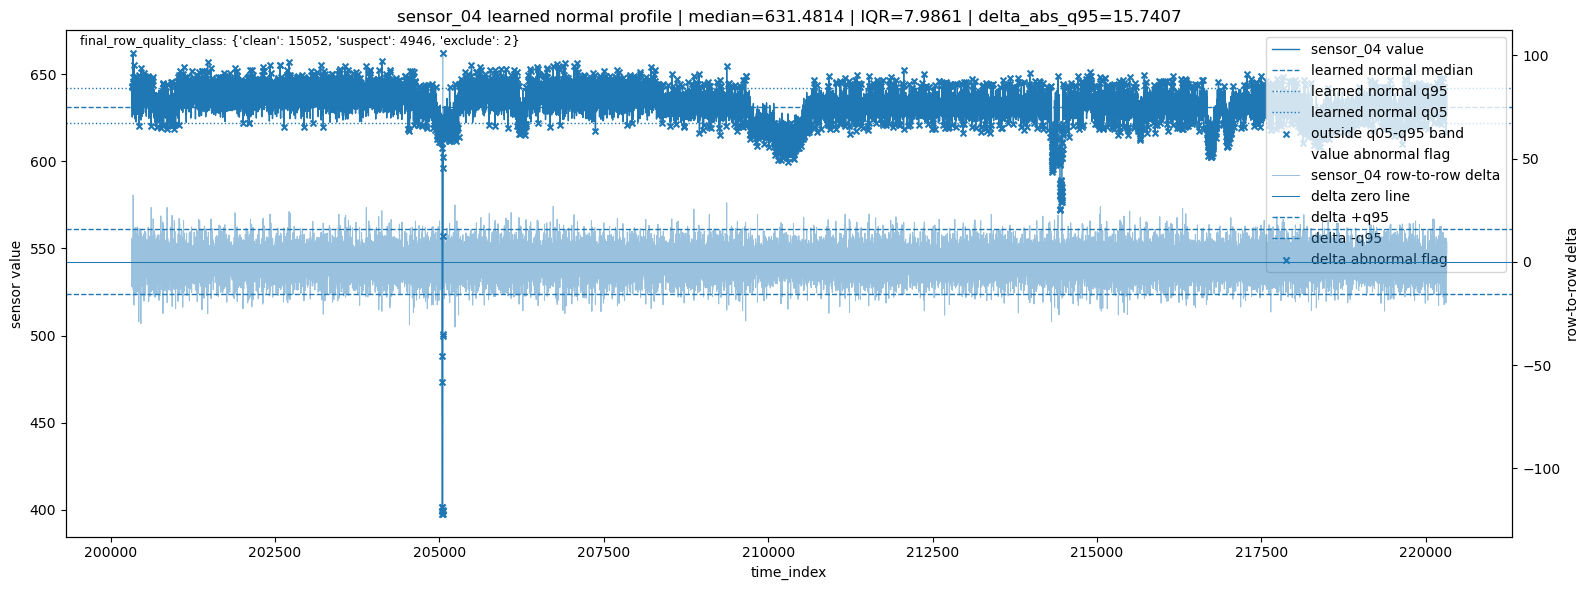

{'figure': <Figure size 1600x600 with 2 Axes>,
 'axes': {'value_axis': <Axes: title={'center': 'sensor_04 learned normal profile | median=631.4814 | IQR=7.9861 | delta_abs_q95=15.7407'}, xlabel='time_index', ylabel='sensor value'>,
  'delta_axis': <Axes: ylabel='row-to-row delta'>},
 'sensor_profile': {'sensor': 'sensor_04',
  'baseline_window_count': 32,
  'baseline_row_count': 122917,
  'baseline_median': 631.4814,
  'baseline_mean': 631.438684860384,
  'baseline_std': 6.059046880985344,
  'baseline_q05': 622.0225675,
  'baseline_q25': 627.4884,
  'baseline_q75': 635.4745,
  'baseline_q95': 642.2019849999999,
  'baseline_iqr': 7.986100000000022,
  'baseline_delta_median': 0.0,
  'baseline_delta_abs_median': 5.20829999999998,
  'baseline_delta_abs_q95': 15.740699999999947,
  'baseline_delta_iqr': 10.368549999999985,
  'baseline_missing_pct': 2.318822656443235e-05},
 'saved_path': None,
 'value_outside_band_count': 3174,
 'value_flag_count': 12,
 'delta_flag_count': 2}

In [86]:
normal_only_df = silver_subset_df[
    silver_subset_df[STATE_COL_SOURCE].astype("string").str.lower().eq("normal")
].copy()

plot_sensor_profile_with_baseline(
    dataframe=normal_only_df,
    baseline_df=final_sensor_baseline_df,
    sensor_name="sensor_04",
    index_column="time_index",
    show_delta=True,
    max_points=20000,
)


## Generate Sensor Profile Plots

### Ask

Why create profile plots for the sensor baseline?

### Answer

The plots give me visual confirmation that the clean-normal baseline makes sense across sensors.

This is useful for documentation and debugging. If a sensor profile looks strange, it may point to missingness, outliers, contamination, or a sensor that should be treated differently downstream.

In [87]:
# =========================================================
# Optional: display/save every sensor profile plot
# =========================================================
# Set SHOW_ALL_SENSOR_PROFILE_PLOTS = True if you want the notebook to
# render all sensor plots inline. Keeping it False still saves PNG files.

SHOW_ALL_SENSOR_PROFILE_PLOTS = False
SENSOR_PROFILE_PLOT_DIR = BASELINE_EXPORT_DIR / "plots"

all_sensor_profile_plot_results = plot_all_sensor_profiles(
    dataframe=normal_only_df,
    baseline_df=final_sensor_baseline_df,
    sensor_columns=SENSOR_COLUMNS,
    index_column="time_index",
    max_points=20000,
    save_dir=SENSOR_PROFILE_PLOT_DIR,
    show_plots=SHOW_ALL_SENSOR_PROFILE_PLOTS,
)

saved_plot_paths = [
    str(result["saved_path"])
    for result in all_sensor_profile_plot_results.values()
    if result["saved_path"] is not None
]

print(f"Saved {len(saved_plot_paths)} sensor profile plots to: {SENSOR_PROFILE_PLOT_DIR}")
display(pd.DataFrame({"saved_plot_path": saved_plot_paths}).head(10))


,metric,value
0,sensor,sensor_00
1,baseline_window_count,32
2,baseline_row_count,122917
3,baseline_median,2.455556
4,baseline_mean,2.453934
5,baseline_std,0.021657
6,baseline_q05,2.420139
7,baseline_q25,2.45162
8,baseline_q75,2.467853
9,baseline_q95,2.499827


,metric,value
0,sensor,sensor_01
1,baseline_window_count,32
2,baseline_row_count,122917
3,baseline_median,47.54774
4,baseline_mean,47.346137
5,baseline_std,1.072892
6,baseline_q05,45.81163
7,baseline_q25,46.614581
8,baseline_q75,48.328993
9,baseline_q95,49.435765


,metric,value
0,sensor,sensor_02
1,baseline_window_count,32
2,baseline_row_count,122917
3,baseline_median,50.911455
4,baseline_mean,51.110853
5,baseline_std,0.889568
6,baseline_q05,49.621308
7,baseline_q25,50.347219
8,baseline_q75,51.90972
9,baseline_q95,52.794049


,metric,value
0,sensor,sensor_03
1,baseline_window_count,32
2,baseline_row_count,122917
3,baseline_median,43.294272
4,baseline_mean,43.532453
5,baseline_std,1.164481
6,baseline_q05,41.905381
7,baseline_q25,42.773436
8,baseline_q75,44.357635
9,baseline_q95,45.768227


,metric,value
0,sensor,sensor_04
1,baseline_window_count,32
2,baseline_row_count,122917
3,baseline_median,631.4814
4,baseline_mean,631.438685
5,baseline_std,6.059047
6,baseline_q05,622.022568
7,baseline_q25,627.4884
8,baseline_q75,635.4745
9,baseline_q95,642.201985


...

,metric,value
0,sensor,sensor_48
1,baseline_window_count,32
2,baseline_row_count,122917
3,baseline_median,122.323475
4,baseline_mean,126.727673
5,baseline_std,38.337685
6,baseline_q05,73.133677
7,baseline_q25,97.07757
8,baseline_q75,154.3692
9,baseline_q95,195.478857


,metric,value
0,sensor,sensor_49
1,baseline_window_count,32
2,baseline_row_count,122917
3,baseline_median,51.215279
4,baseline_mean,51.765315
5,baseline_std,5.575393
6,baseline_q05,45.283565
7,baseline_q25,48.03241
8,baseline_q75,54.1088
9,baseline_q95,60.908565


,metric,value
0,sensor,sensor_51
1,baseline_window_count,32
2,baseline_row_count,122917
3,baseline_median,193.28705
4,baseline_mean,197.131555
5,baseline_std,23.474115
6,baseline_q05,159.8669
7,baseline_q25,181.13425
8,baseline_q75,208.044
9,baseline_q95,238.42595


Saved 50 sensor profile plots to: /workspace/artifacts/silver/pump/eda/sensor_profiles/plots


,saved_plot_path
0,/workspace/artifacts/silver/pump/eda/sensor_pr...
1,/workspace/artifacts/silver/pump/eda/sensor_pr...
2,/workspace/artifacts/silver/pump/eda/sensor_pr...
3,/workspace/artifacts/silver/pump/eda/sensor_pr...
4,/workspace/artifacts/silver/pump/eda/sensor_pr...
5,/workspace/artifacts/silver/pump/eda/sensor_pr...
6,/workspace/artifacts/silver/pump/eda/sensor_pr...
7,/workspace/artifacts/silver/pump/eda/sensor_pr...
8,/workspace/artifacts/silver/pump/eda/sensor_pr...
9,/workspace/artifacts/silver/pump/eda/sensor_pr...


,metric,value
0,sensor,sensor_00
1,baseline_window_count,32
2,baseline_row_count,122917
3,baseline_median,2.455556
4,baseline_mean,2.453934
5,baseline_std,0.021657
6,baseline_q05,2.420139
7,baseline_q25,2.45162
8,baseline_q75,2.467853
9,baseline_q95,2.499827


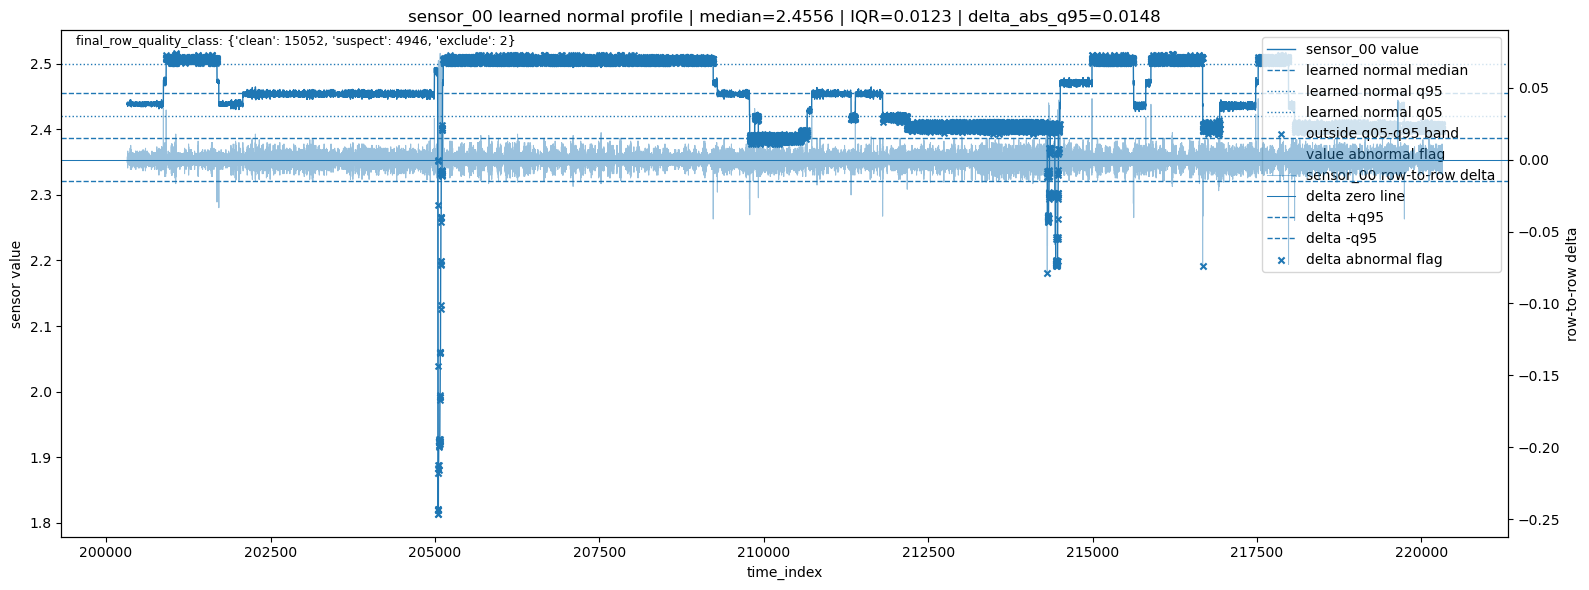

,metric,value
0,sensor,sensor_04
1,baseline_window_count,32
2,baseline_row_count,122917
3,baseline_median,631.4814
4,baseline_mean,631.438685
5,baseline_std,6.059047
6,baseline_q05,622.022568
7,baseline_q25,627.4884
8,baseline_q75,635.4745
9,baseline_q95,642.201985


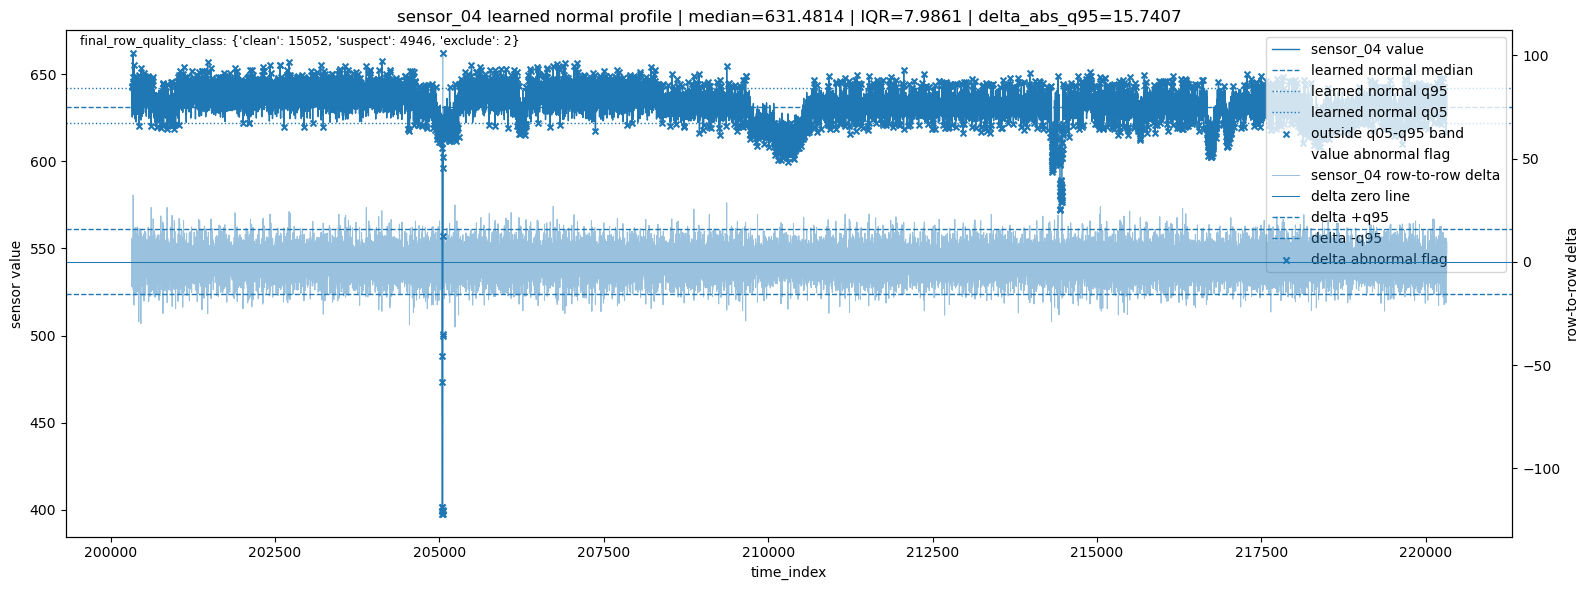

,metric,value
0,sensor,sensor_14
1,baseline_window_count,32
2,baseline_row_count,122917
3,baseline_median,420.3776
4,baseline_mean,420.083702
5,baseline_std,3.058667
6,baseline_q05,418.200325
7,baseline_q25,419.648062
8,baseline_q75,420.984375
9,baseline_q95,421.958955


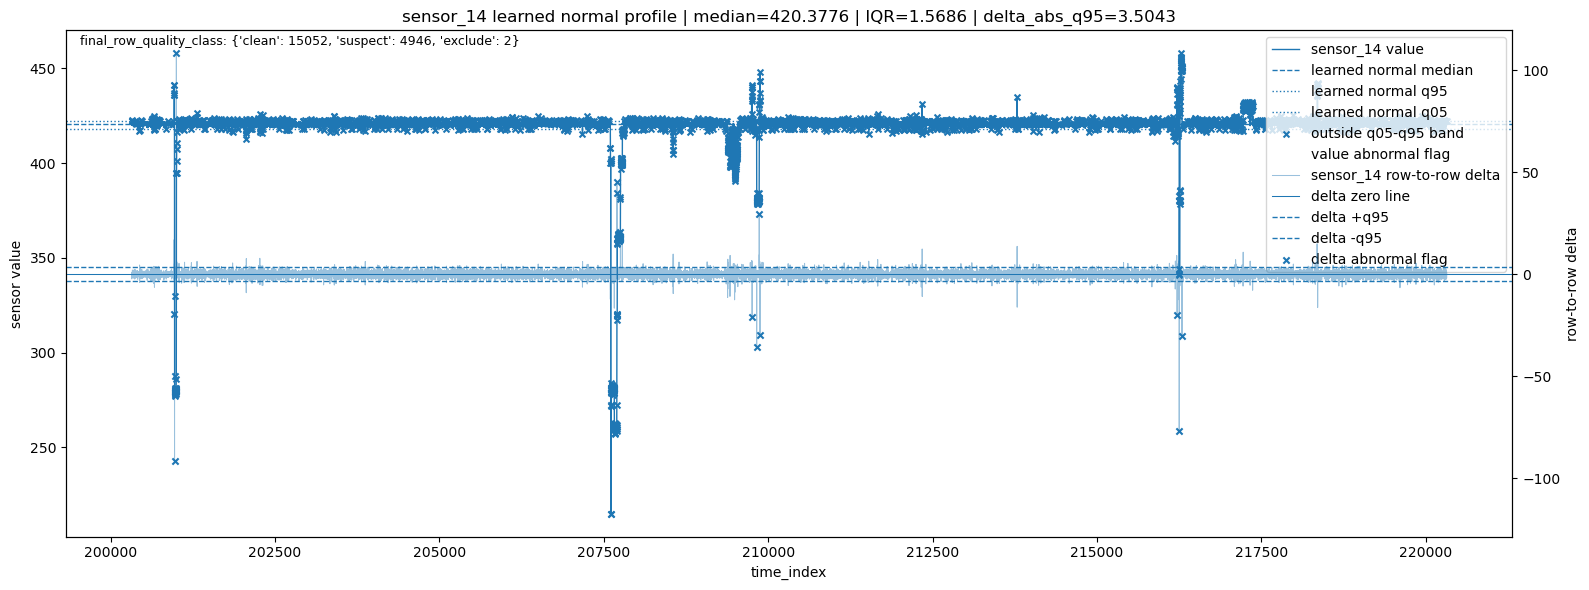

,metric,value
0,sensor,sensor_20
1,baseline_window_count,32
2,baseline_row_count,122917
3,baseline_median,399.54655
4,baseline_mean,399.519213
5,baseline_std,0.953198
6,baseline_q05,398.11018
7,baseline_q25,399.00595
8,baseline_q75,400.1182
9,baseline_q95,400.962675


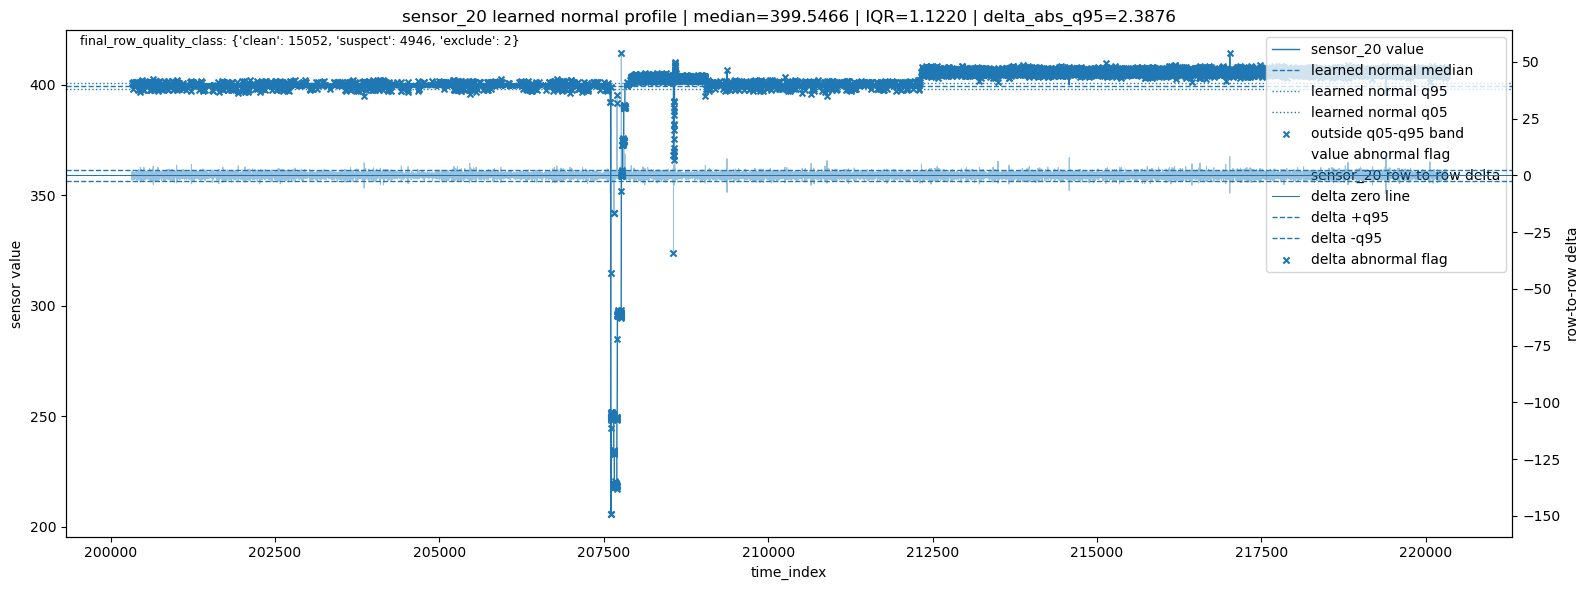

In [88]:
# =========================================================
# Quick visual check for selected sensors
# =========================================================

for sensor_name in ["sensor_00", "sensor_04", "sensor_14", "sensor_20"]:
    if sensor_name in SENSOR_COLUMNS:
        display_sensor_profile(
            baseline_df=final_sensor_baseline_df,
            sensor_name=sensor_name,
        )

        plot_sensor_profile_with_baseline(
            dataframe=normal_only_df,
            baseline_df=final_sensor_baseline_df,
            sensor_name=sensor_name,
            index_column="time_index",
            show_delta=True,
            max_points=20000,
        )


## Create a Focused Sensor Baseline Plot

### Ask

Why use a focused single-sensor plot?

### Answer

A focused plot lets me inspect one sensor in more detail.

This is useful when I want to validate a specific sensor that appears important, unstable, or potentially related to fault behavior. It gives me a clearer view than a broad all-sensor summary.

In [89]:
import matplotlib.pyplot as plt


def plot_sensor_profile_with_baseline(
    dataframe,
    baseline_df,
    sensor_name,
    *,
    index_column=None,
    quality_column="final_row_quality_class",
    figsize=(16, 6),
    show_delta=True,
    max_points=None,
):
    plot_df = dataframe.copy()

    if max_points is not None and len(plot_df) > max_points:
        plot_df = plot_df.iloc[-max_points:].copy()

    sensor_profile = (
        baseline_df
        .loc[baseline_df["sensor"].eq(sensor_name)]
        .iloc[0]
    )

    baseline_median = sensor_profile["baseline_median"]
    baseline_q05 = sensor_profile["baseline_q05"]
    baseline_q95 = sensor_profile["baseline_q95"]
    baseline_iqr = sensor_profile["baseline_iqr"]
    baseline_delta_abs_q95 = sensor_profile["baseline_delta_abs_q95"]

    if index_column is not None and index_column in plot_df.columns:
        x_values = plot_df[index_column]
        x_label = index_column
    else:
        x_values = plot_df.index
        x_label = "row_index"

    upper_normal_band = baseline_q95
    lower_normal_band = baseline_q05

    value_outside_normal_band = (
        plot_df[sensor_name].lt(lower_normal_band)
        | plot_df[sensor_name].gt(upper_normal_band)
    )

    fig, ax1 = plt.subplots(figsize=figsize)

    ax1.plot(
        x_values,
        plot_df[sensor_name],
        linewidth=1,
        label=f"{sensor_name} value",
    )

    ax1.axhline(
        baseline_median,
        linestyle="--",
        linewidth=1,
        label="baseline median",
    )

    ax1.axhline(
        upper_normal_band,
        linestyle=":",
        linewidth=1,
        label="baseline q95",
    )

    ax1.axhline(
        lower_normal_band,
        linestyle=":",
        linewidth=1,
        label="baseline q05",
    )

    ax1.scatter(
        x_values[value_outside_normal_band],
        plot_df.loc[value_outside_normal_band, sensor_name],
        s=12,
        marker="x",
        label="outside baseline band",
    )

    ax1.set_title(
        f"{sensor_name} Profile Check | "
        f"Median={baseline_median:.4f}, IQR={baseline_iqr:.4f}, "
        f"Delta q95={baseline_delta_abs_q95:.4f}"
    )

    ax1.set_xlabel(x_label)
    ax1.set_ylabel("sensor value")

    if show_delta:
        sensor_delta = plot_df[sensor_name].diff()

        ax2 = ax1.twinx()

        ax2.plot(
            x_values,
            sensor_delta,
            linewidth=0.75,
            alpha=0.45,
            label=f"{sensor_name} delta",
        )

        ax2.axhline(
            baseline_delta_abs_q95,
            linestyle="--",
            linewidth=1,
            label="delta +q95",
        )

        ax2.axhline(
            -baseline_delta_abs_q95,
            linestyle="--",
            linewidth=1,
            label="delta -q95",
        )

        ax2.set_ylabel("row-to-row delta")

        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()

        ax1.legend(
            lines_1 + lines_2,
            labels_1 + labels_2,
            loc="upper right",
        )
    else:
        ax1.legend(loc="upper right")

    plt.tight_layout()
    plt.show()



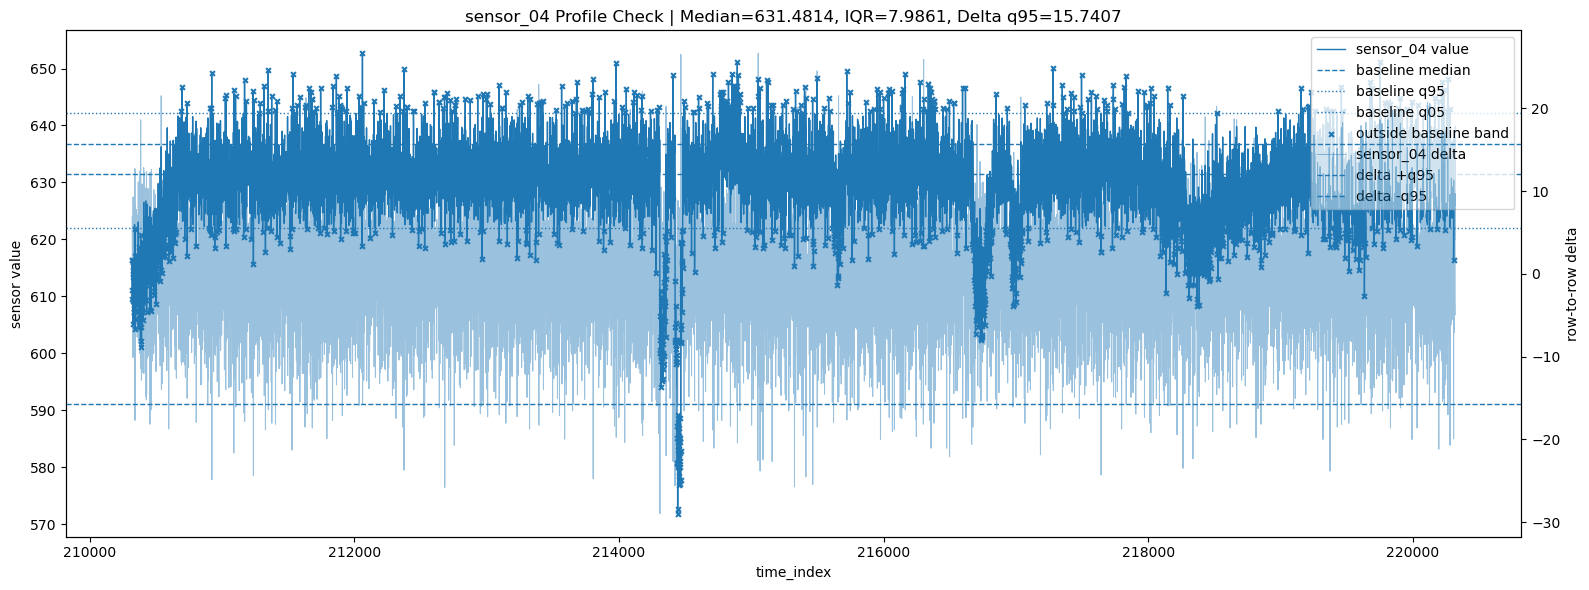

In [90]:
plot_sensor_profile_with_baseline(
    dataframe=silver_subset_df,
    baseline_df=final_sensor_baseline_df,
    sensor_name="sensor_04",
    index_column="time_index",
    show_delta=True,
    max_points=10000,
)

---

## Define Final Profiled-State Mapping

### Ask

What final labels am I standardizing here?

### Answer

This cell standardizes the source and profiled state labels used by the final subset output.

I want these labels to be explicit and consistent because they become part of the saved profiled dataframe. Later notebooks should not need to guess what values represent clean normal, contaminated normal, abnormal, or recovery behavior.

In [91]:
# =========================================================
# Build profiled state column
# =========================================================

STATE_COL_SOURCE = "machine_status__synthetic"
STATE_COL_PROFILED = "machine_status__profiled"

SOURCE_NORMAL_VALUE = "normal"
SOURCE_ABNORMAL_VALUE = "abnormal"
SOURCE_RECOVERY_VALUE = "recovery"

PROFILED_NORMAL_CLEAN_VALUE = "normal_clean"
PROFILED_NORMAL_SUSPECT_VALUE = "normal_suspect"
PROFILED_NORMAL_CONTAMINATED_VALUE = "normal_contaminated"
PROFILED_ABNORMAL_VALUE = "abnormal"
PROFILED_RECOVERY_VALUE = "recovery"

silver_subset_df = scored_normal_quality_df.copy()

silver_subset_df["final_row_quality_class"] = (
    silver_subset_df["normal_training_quality_class"]
)

silver_subset_df["row_is_clean_normal"] = (
    silver_subset_df["final_row_quality_class"].astype("string").eq("clean")
)

silver_subset_df["row_is_suspect_normal"] = (
    silver_subset_df["final_row_quality_class"].astype("string").eq("suspect")
)

silver_subset_df["row_is_exclude_from_normal_training"] = (
    silver_subset_df["final_row_quality_class"]
    .astype("string")
    .isin(["suspect", "exclude"])
)

silver_subset_df[STATE_COL_PROFILED] = (
    silver_subset_df[STATE_COL_SOURCE]
    .astype("string")
    .str.lower()
)

mask_source_normal = silver_subset_df[STATE_COL_SOURCE].astype("string").str.lower().eq(SOURCE_NORMAL_VALUE)
mask_source_abnormal = silver_subset_df[STATE_COL_SOURCE].astype("string").str.lower().eq(SOURCE_ABNORMAL_VALUE)
mask_source_recovery = silver_subset_df[STATE_COL_SOURCE].astype("string").str.lower().eq(SOURCE_RECOVERY_VALUE)

quality_class = silver_subset_df["final_row_quality_class"].astype("string").str.lower()

mask_normal_clean = mask_source_normal & quality_class.eq("clean")
mask_normal_suspect = mask_source_normal & quality_class.eq("suspect")
mask_normal_exclude = mask_source_normal & quality_class.eq("exclude")

silver_subset_df.loc[mask_normal_clean, STATE_COL_PROFILED] = PROFILED_NORMAL_CLEAN_VALUE
silver_subset_df.loc[mask_normal_suspect, STATE_COL_PROFILED] = PROFILED_NORMAL_SUSPECT_VALUE
silver_subset_df.loc[mask_normal_exclude, STATE_COL_PROFILED] = PROFILED_NORMAL_CONTAMINATED_VALUE
silver_subset_df.loc[mask_source_abnormal, STATE_COL_PROFILED] = PROFILED_ABNORMAL_VALUE
silver_subset_df.loc[mask_source_recovery, STATE_COL_PROFILED] = PROFILED_RECOVERY_VALUE

profiled_state_counts_df = (
    silver_subset_df[STATE_COL_PROFILED]
    .value_counts(dropna=False)
    .rename_axis(STATE_COL_PROFILED)
    .reset_index(name="row_count")
)

profiled_state_counts_df["row_pct"] = (
    profiled_state_counts_df["row_count"] / len(silver_subset_df)
)

final_quality_counts_df = (
    silver_subset_df["final_row_quality_class"]
    .value_counts(dropna=False)
    .rename_axis("final_row_quality_class")
    .reset_index(name="row_count")
)

final_quality_counts_df["row_pct"] = (
    final_quality_counts_df["row_count"] / len(silver_subset_df)
)

display(profiled_state_counts_df)
display(final_quality_counts_df)

,machine_status__profiled,row_count,row_pct
0,normal_clean,153885,0.698461
1,normal_suspect,33269,0.151003
2,normal_contaminated,18682,0.084795
3,recovery,14477,0.065709
4,abnormal,7,0.000032


,final_row_quality_class,row_count,row_pct
0,clean,153885,0.698461
1,suspect,33269,0.151003
2,exclude,18682,0.084795
3,not_normal,14484,0.065741


## Save the Profiled Subset Artifacts

### Ask

What is the final output of Silver 02a?

### Answer

This final section saves the profiled Silver dataframe and the supporting subset artifacts.

The important output is the dataframe with `machine_status__profiled`, because that becomes the input for Silver 02b and Gold preprocessing. The saved artifacts also preserve the profiling decisions so the clean-normal construction can be reviewed and reused.

In [92]:
# =========================================================
# Save subset outputs
# - parquet files -> data directory for downstream Gold use
# - summary json   -> artifact directory for diagnostics/traceability
# =========================================================

# Data output directory for downstream pipeline consumption
#SILVER_SUBSET_DATA_DIR = SILVER_TRAIN_DATA_PATH / "subset_outputs" / DATASET_NAME
SILVER_SUBSET_DATA_DIR = SILVER_TRAIN_DATA_PATH 
SILVER_SUBSET_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Artifact output directory for notebook diagnostics / summary metadata
subset_artifact_dir = SILVER_SUBSET_ARTIFACT_DIR
subset_artifact_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Data files Gold should read
# -----------------------------
profiled_df_path = (
    SILVER_SUBSET_DATA_DIR
    / f"{DATASET_NAME}__silver_subsets__profiled_dataframe.parquet"
)

normal_clean_path = (
    SILVER_SUBSET_DATA_DIR
    / f"{DATASET_NAME}__silver_subsets__normal_clean.parquet"
)

normal_contaminated_path = (
    SILVER_SUBSET_DATA_DIR
    / f"{DATASET_NAME}__silver_subsets__normal_contaminated.parquet"
)

'''
# Optional: clean training-only alias for Gold
gold_train_normal_clean_path = (
    SILVER_SUBSET_DATA_DIR
    / f"{DATASET_NAME}__gold_train__normal_clean.parquet"
)
'''

# -----------------------------
# Artifact summary file
# -----------------------------
subset_summary_path = (
    SILVER_SUBSET_SUMMARY_DIR
    / f"{DATASET_NAME}__silver_subsets__summary.json"
)

# -----------------------------
# Save parquet data outputs
# -----------------------------
silver_subset_df.to_parquet(profiled_df_path, index=False)

silver_subset_df.loc[
    silver_subset_df[STATE_COL_PROFILED].eq(PROFILED_NORMAL_CLEAN_VALUE)
].to_parquet(normal_clean_path, index=False)

silver_subset_df.loc[
    silver_subset_df[STATE_COL_PROFILED].eq(PROFILED_NORMAL_CONTAMINATED_VALUE)
].to_parquet(normal_contaminated_path, index=False)

'''
# Optional alias file specifically named for Gold training input
silver_subset_df.loc[
    silver_subset_df[STATE_COL_PROFILED].eq(PROFILED_NORMAL_CLEAN_VALUE)
].to_parquet(gold_train_normal_clean_path, index=False)
'''

# -----------------------------
# Build and save summary json
# -----------------------------
subset_summary = {
    "dataset_name": DATASET_NAME,
    "stage": STAGE,
    "final_method": FINAL_METHOD,
    "state_col_source": STATE_COL_SOURCE,
    "state_col_profiled": STATE_COL_PROFILED,
    "source_counts": silver_subset_df[STATE_COL_SOURCE].value_counts(dropna=False).to_dict(),
    "profiled_counts": silver_subset_df[STATE_COL_PROFILED].value_counts(dropna=False).to_dict(),
    "final_row_quality_counts": silver_subset_df["final_row_quality_class"].value_counts(dropna=False).to_dict(),
    "sensor_baseline_json_path": str(baseline_json_path) if "baseline_json_path" in globals() else None,
    "sensor_baseline_table_path": str(baseline_table_path) if "baseline_table_path" in globals() else None,
    "sensor_profile_plot_dir": str(SENSOR_PROFILE_PLOT_DIR) if "SENSOR_PROFILE_PLOT_DIR" in globals() else None,
    "profiled_df_path": str(profiled_df_path),
    "normal_clean_path": str(normal_clean_path),
    "normal_contaminated_path": str(normal_contaminated_path),
    #"gold_train_normal_clean_path": str(gold_train_normal_clean_path),
    "subset_data_dir": str(SILVER_SUBSET_DATA_DIR),
    "subset_artifact_dir": str(subset_artifact_dir),
}

with open(subset_summary_path, "w", encoding="utf-8") as f:
    json.dump(subset_summary, f, indent=2)

ledger.add(
    kind="step",
    step="save_subset_outputs",
    message="Saved profiled subset parquet outputs to the data directory and summary metadata to the artifact directory.",
    data={
        "profiled_df_path": str(profiled_df_path),
        "normal_clean_path": str(normal_clean_path),
        "normal_contaminated_path": str(normal_contaminated_path),
        #"gold_train_normal_clean_path": str(gold_train_normal_clean_path),
        "subset_summary_path": str(subset_summary_path),
    },
    logger=logger,
)

print("Saved data:", profiled_df_path)
print("Saved data:", normal_clean_path)
print("Saved data:", normal_contaminated_path)
#print("Saved data:", gold_train_normal_clean_path)
print("Saved artifact summary:", subset_summary_path)

2026-06-02 05:10:26,555 | INFO | capstone.silver_subsets | LEDGER | {'ts_utc': '2026-06-02T05:10:26.555328+00:00', 'stage': 'silver_subsets', 'recipe': 'silver_subsets__v001', 'kind': 'step', 'step': 'save_subset_outputs', 'message': 'Saved profiled subset parquet outputs to the data directory and summary metadata to the artifact directory.', 'why': None, 'consequence': None, 'data': {'profiled_df_path': '/workspace/data/silver/train/pump__silver_subsets__profiled_dataframe.parquet', 'normal_clean_path': '/workspace/data/silver/train/pump__silver_subsets__normal_clean.parquet', 'normal_contaminated_path': '/workspace/data/silver/train/pump__silver_subsets__normal_contaminated.parquet', 'subset_summary_path': '/workspace/artifacts/silver/pump/eda/summaries/pump__silver_subsets__summary.json'}}


Saved data: /workspace/data/silver/train/pump__silver_subsets__profiled_dataframe.parquet
Saved data: /workspace/data/silver/train/pump__silver_subsets__normal_clean.parquet
Saved data: /workspace/data/silver/train/pump__silver_subsets__normal_contaminated.parquet
Saved artifact summary: /workspace/artifacts/silver/pump/eda/summaries/pump__silver_subsets__summary.json


---

# Silver EDA SQL Logging Cell
Target:
- capstone.pipeline_runs
- capstone.data_quality_events
- capstone.pipeline_artifacts

Purpose:
- Log Silver EDA summary information to SQL metadata tables without duplicating every EDA artifact in the database.


In [ ]:

WRITE_TO_POSTGRES = True

if WRITE_TO_POSTGRES:

    silver_eda_sql_summary_dataframe = log_silver_eda_sql(
        engine=engine,
        capstone_schema=CAPSTONE_SCHEMA,
        dataset_id=DATASET_ID,
        run_id=RUN_ID,
        notebook_globals=globals(),
        dataset_name=globals().get("DATASET_NAME", DATASET_ID),
    )

    display(silver_eda_sql_summary_dataframe)
else:
    print("Postgres write skipped.")

Postgres write skipped.
